In [3]:
from sklearn.model_selection import cross_val_score, KFold, cross_validate, RepeatedKFold
from sklearn.preprocessing import PowerTransformer, RobustScaler, StandardScaler
from sklearn.feature_selection import VarianceThreshold, RFECV, RFE
from sklearn.linear_model import LinearRegression


from ml_enhance import plot_scaled_linreg_result, CorrelationFilter


import matplotlib.pyplot as plt
from sklearn import pipeline
import seaborn as sns
import pandas as pd
import numpy as np
import scipy
import json

In [53]:
def make_pipeline(model, step_name):
    return pipeline.Pipeline([
        ("variance", VarianceThreshold(threshold=0.0)),
        ("remove_corr", CorrelationFilter(threshold=0.8)),
        ("transform", PowerTransformer(method='yeo-johnson', standardize=False)),
        ("scale", StandardScaler()),
        (step_name, model)
    ])

In [54]:
pl_linear = make_pipeline(LinearRegression(), "predict")

In [55]:
df = pd.read_csv("../data/processed_dataset_rerun.csv")

# df = df.drop("avg_atomic_quadrupole_principal_invariant_3", axis=1)
# df = df.drop("min_atomic_quadrupole_principal_invariant_3", axis=1)
# df = df.drop("max_atomic_quadrupole_principal_invariant_3", axis=1)
# df = df.drop("min_overlap_integral", axis=1)

# df = df.drop(197)

y = df["solubility"]
X = df.drop(["solubility", "smiles", "canon_smiles", "id"], axis=1)

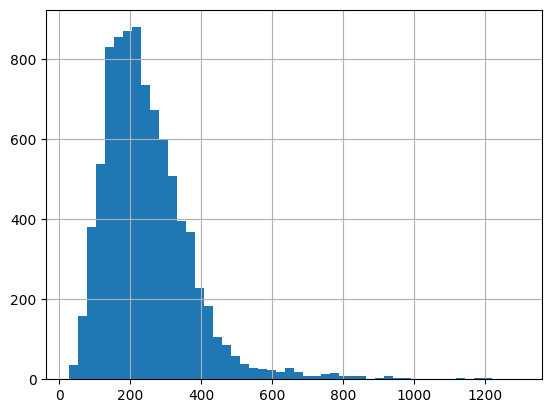

In [56]:
X["MolWt"].hist(bins=50)
plt.show()

In [57]:
X_trans = pl_linear[:-1].fit_transform(X)
X_trans_df = pd.DataFrame(
    X_trans,
    columns=pl_linear[:-1].get_feature_names_out()    
)

In [58]:
X_trans_df.columns

Index(['atomization_energy', 'homo_lumo_gap', 'ionization_energy',
       'molecular_dipole_norm', 'molecular_quadrupole_principal_invariant_2',
       'molecular_quadrupole_principal_invariant_3',
       'molecular_polarizability_mean', 'molecular_polarizability_anisotropy',
       'sterimol_Bmin', 'solvation_energy_water',
       ...
       'fr_quatN', 'fr_sulfide', 'fr_sulfonamd', 'fr_sulfone',
       'fr_term_acetylene', 'fr_tetrazole', 'fr_thiazole', 'fr_thiocyan',
       'fr_thiophene', 'fr_urea'],
      dtype='str', length=207)

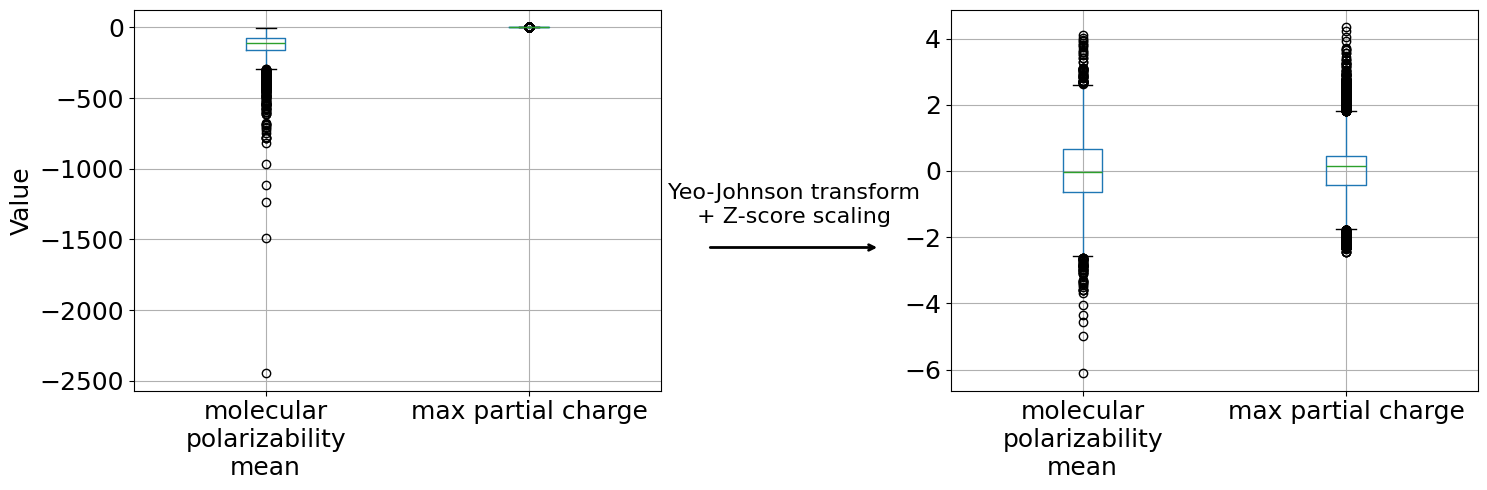

In [15]:
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

X[["molecular_polarizability_mean", "max_partial_charge"]].boxplot(ax=ax1)
X_trans_df[["molecular_polarizability_mean", "max_partial_charge"]].boxplot(ax=ax2)
ax1.set_ylabel("Value", fontsize=18)

ax1.tick_params(axis='both', labelsize=18)
ax2.tick_params(axis='both', labelsize=18)

ax1.set_xticklabels(["molecular\npolarizability\nmean", "max partial charge"])
ax2.set_xticklabels(["molecular\npolarizability\nmean", "max partial charge"])
 
fig.subplots_adjust(wspace=0.5)

# Get axes positions in figure coordinates
p1 = ax1.get_position()
p2 = ax2.get_position()

# Arrow between axes
x_start = p1.x1 + 0.04
x_end = p2.x0
y = (p1.y0 + p1.y1) / 2

ax1.annotate(
    "",
    xy=(x_end, y),
    xytext=(x_start, y),
    xycoords=fig.transFigure,
    textcoords=fig.transFigure,
    arrowprops=dict(arrowstyle="->", lw=2)
)

# Text above arrow
fig.text(
    (x_start + x_end) / 2,
    y + 0.05,
    "Yeo-Johnson transform\n+ Z-score scaling",
    fontsize=16,
    ha="center"
)

plt.tight_layout()
# plt.savefig("transform.pdf", format="pdf")
plt.show()

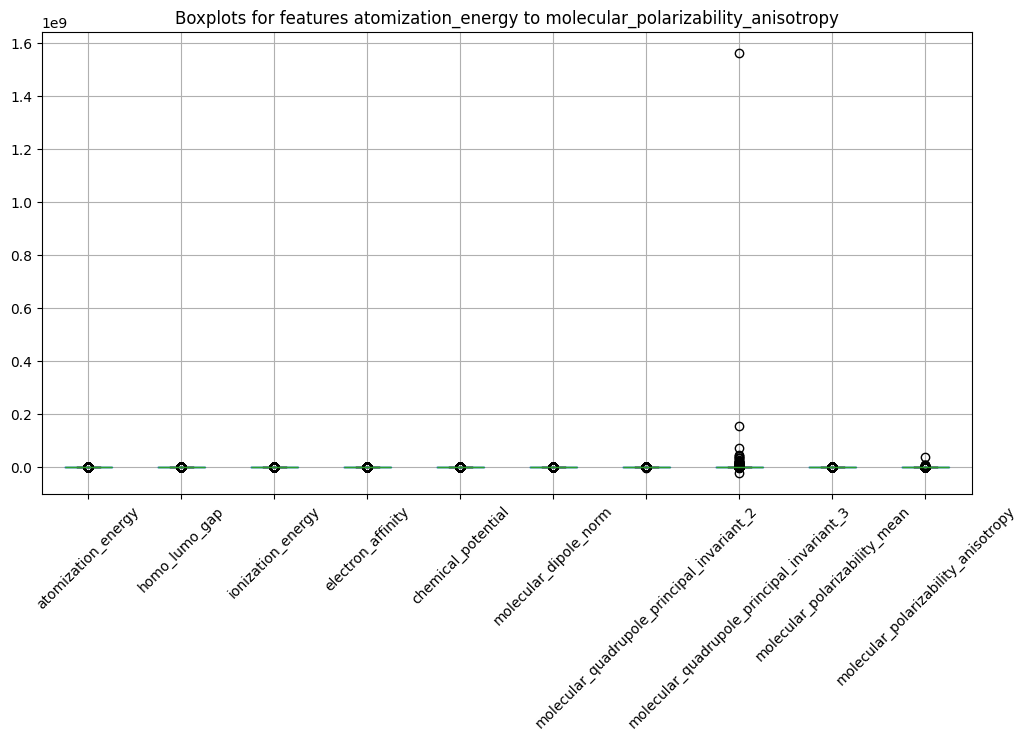

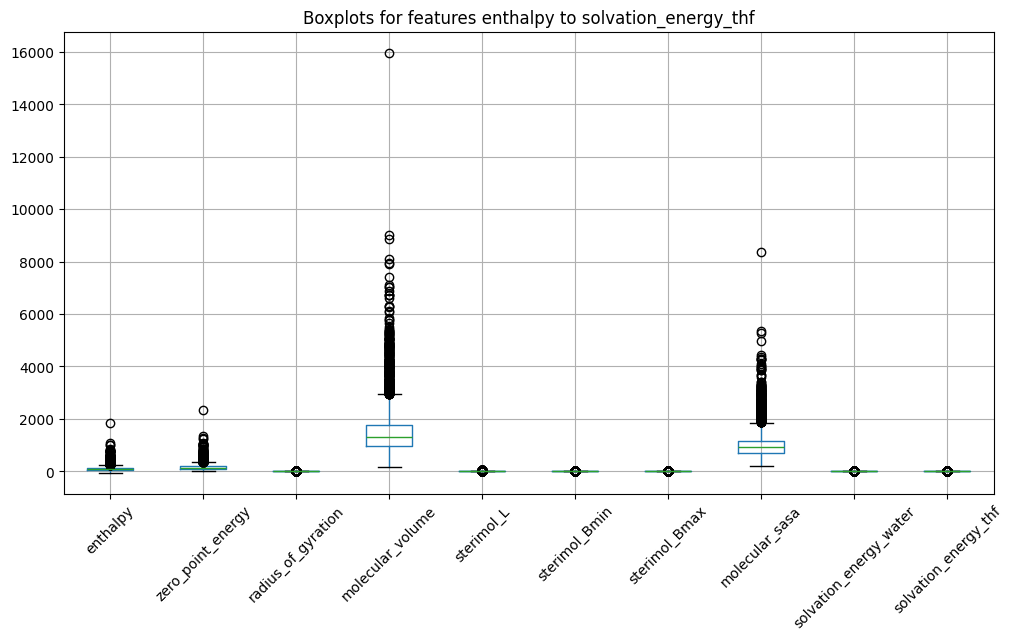

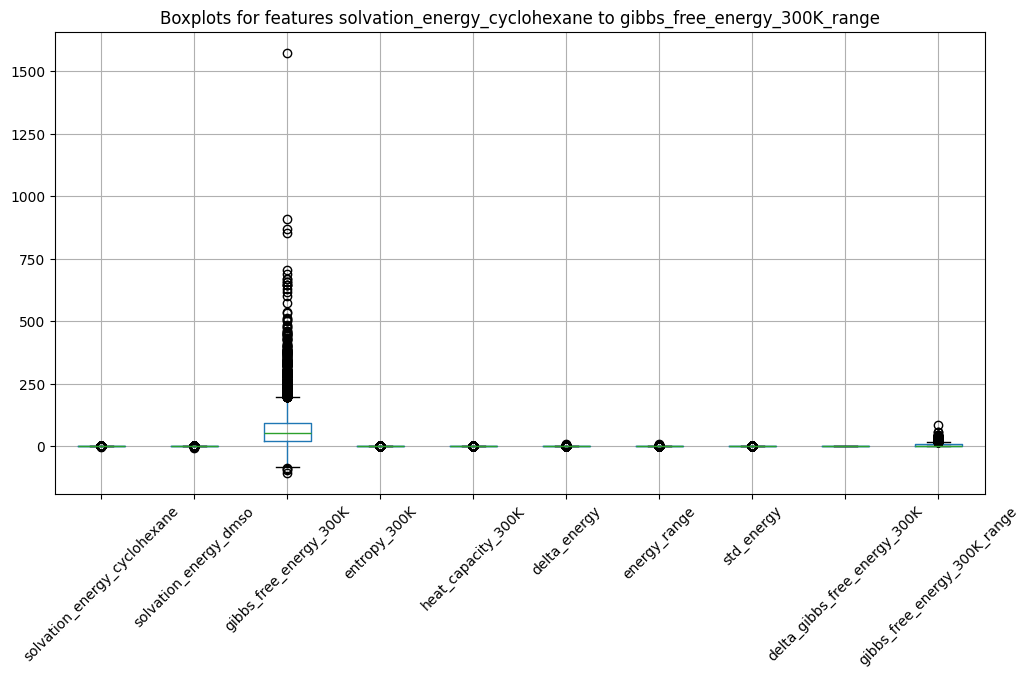

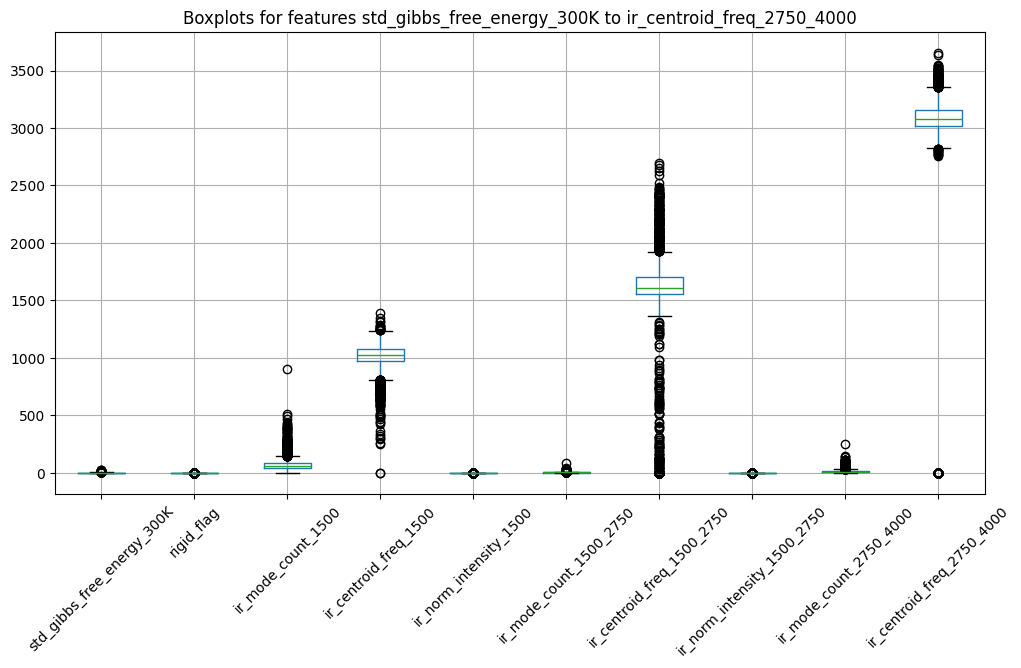

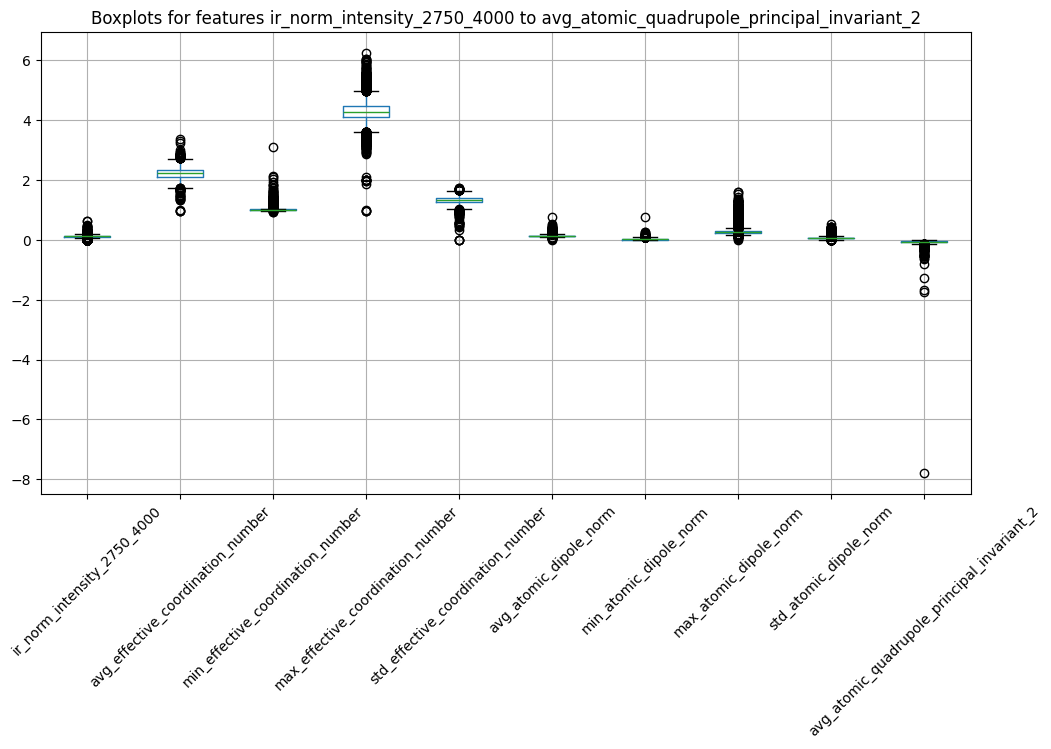

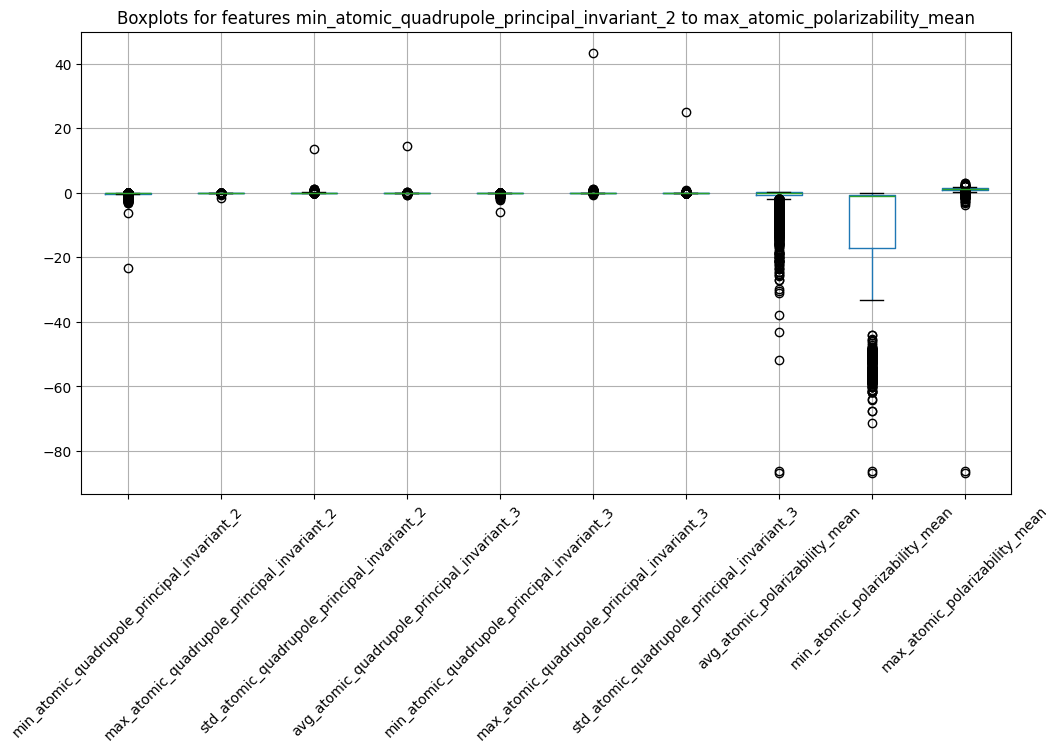

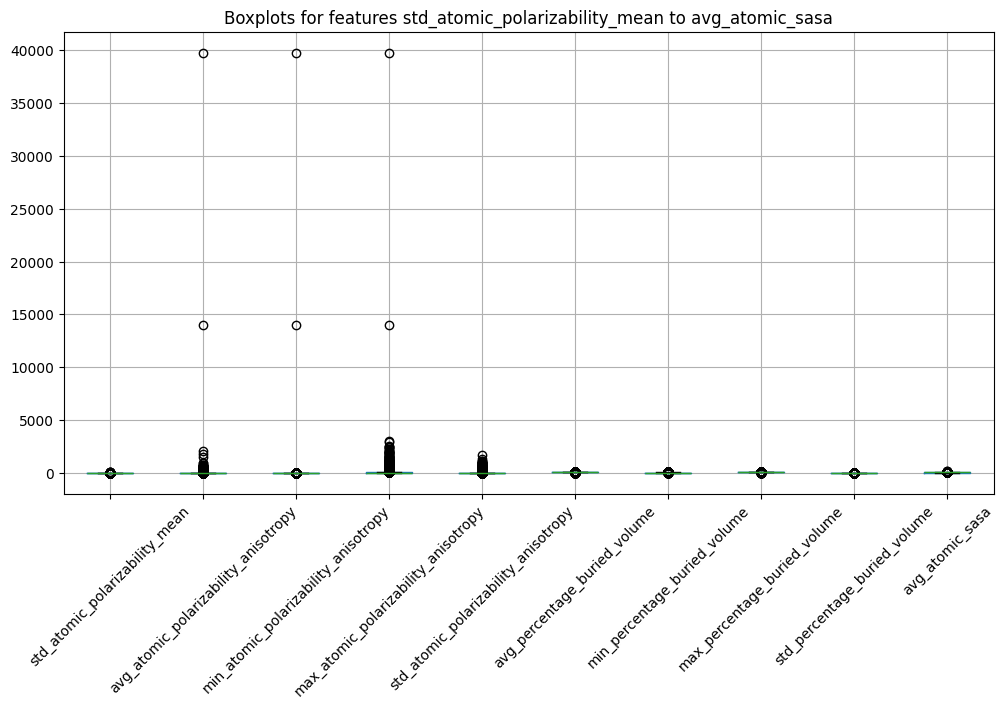

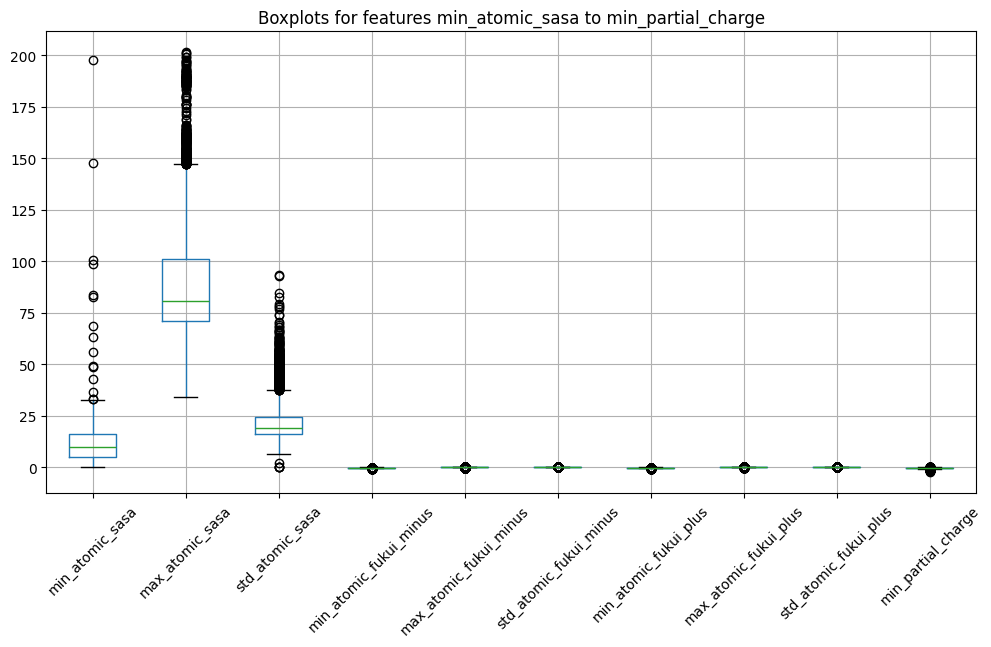

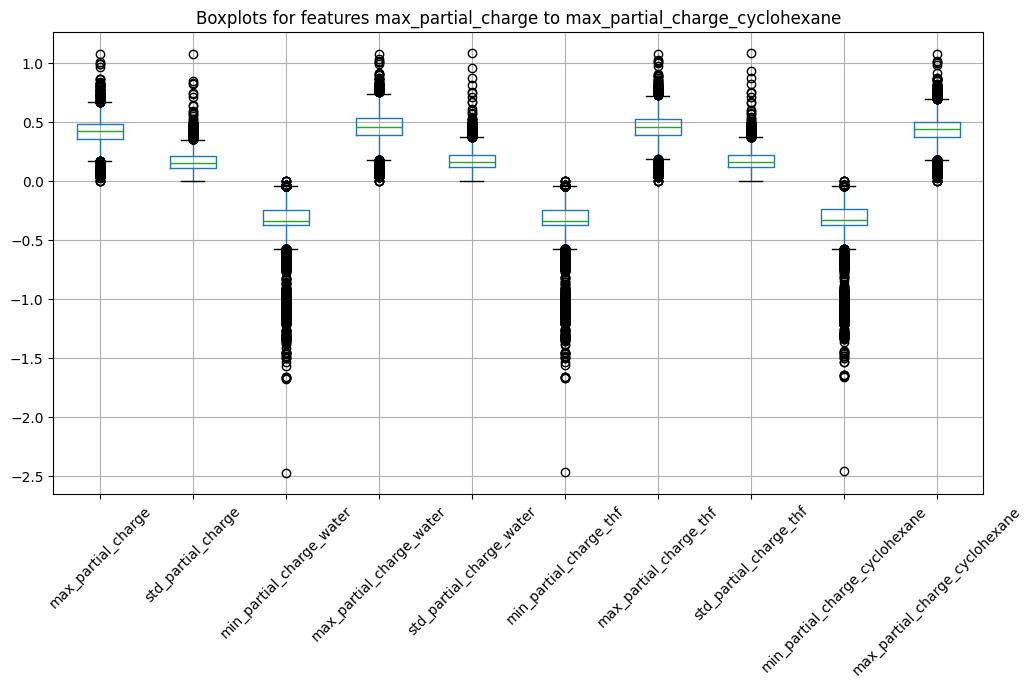

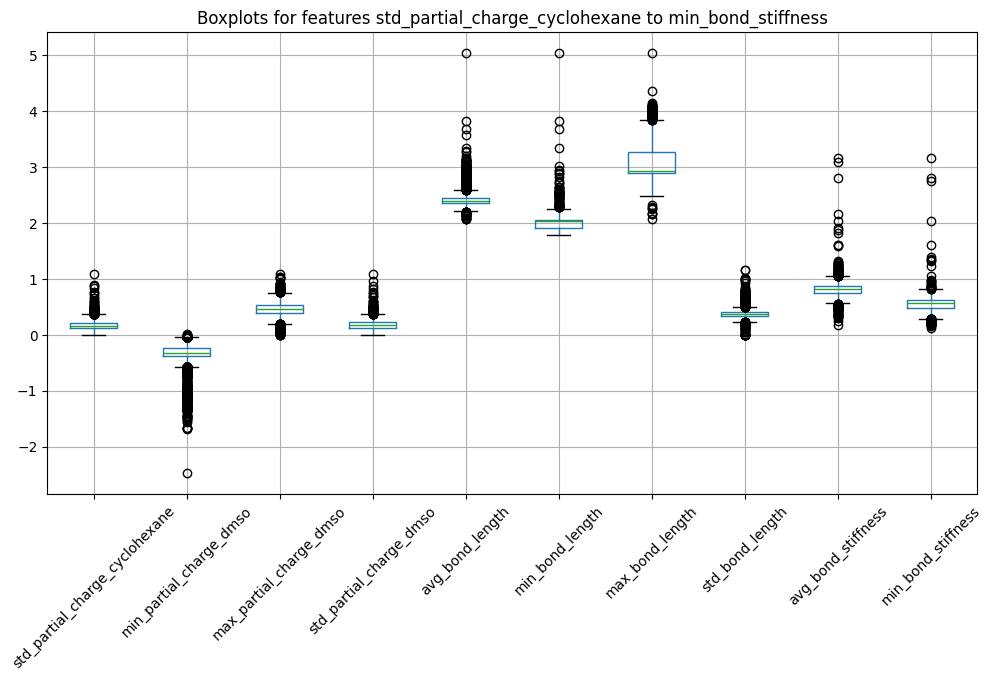

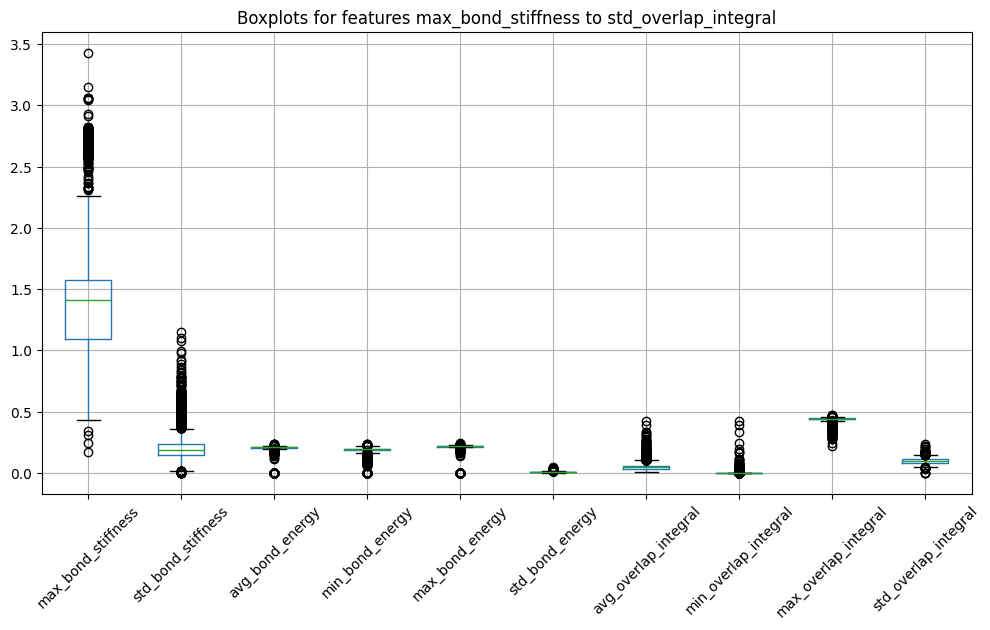

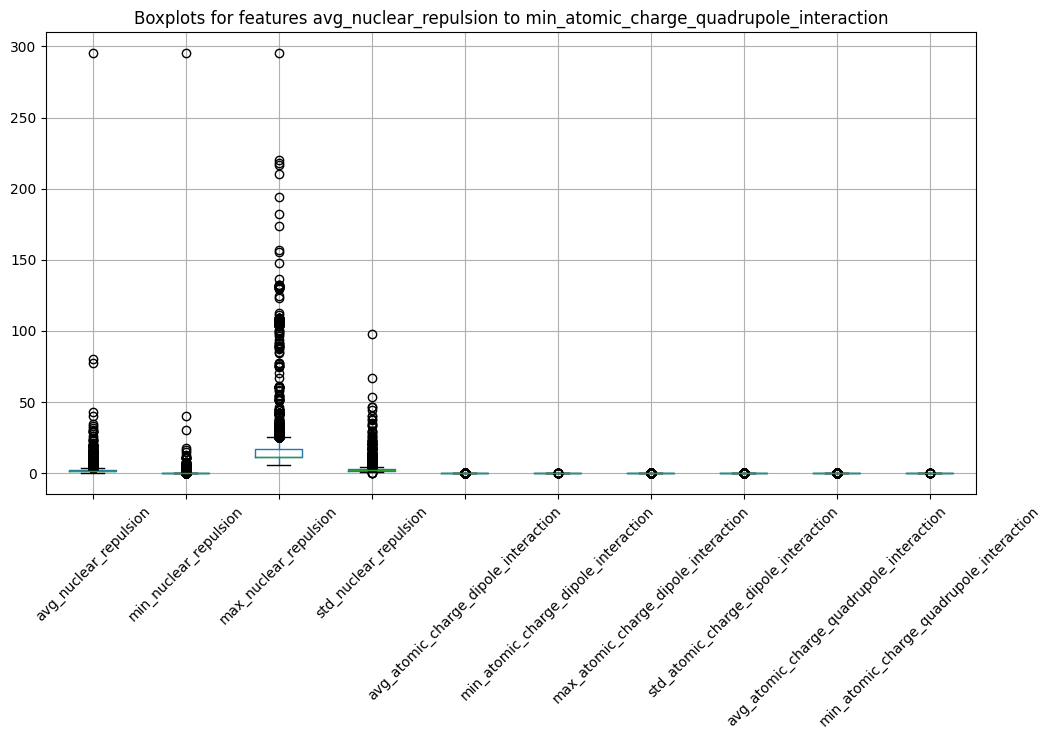

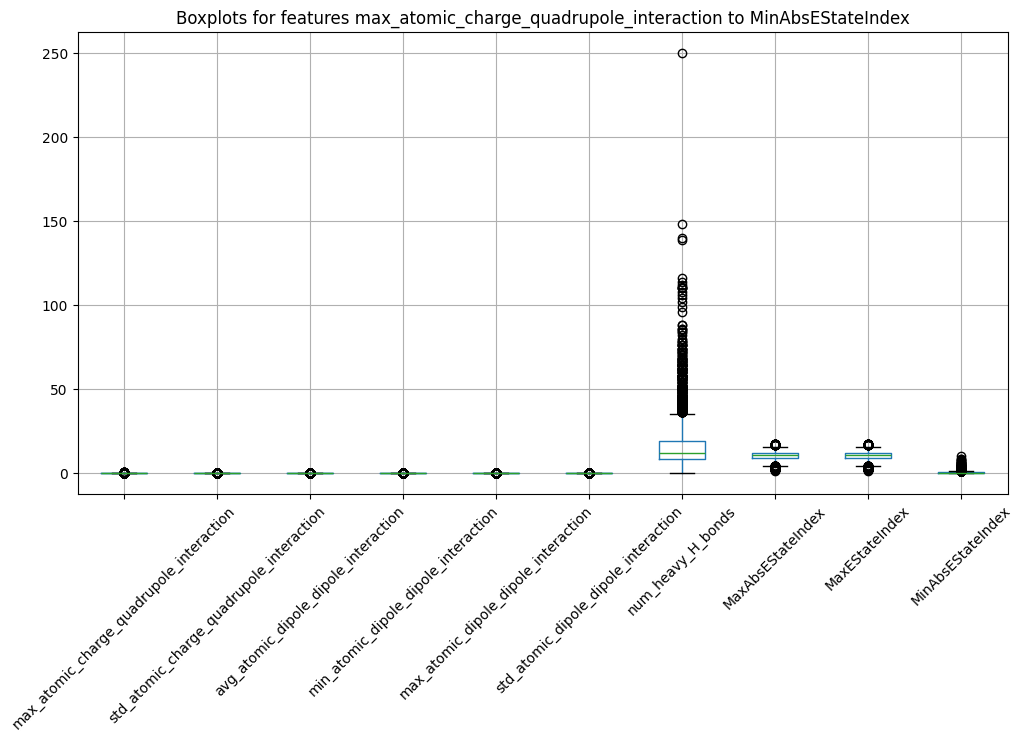

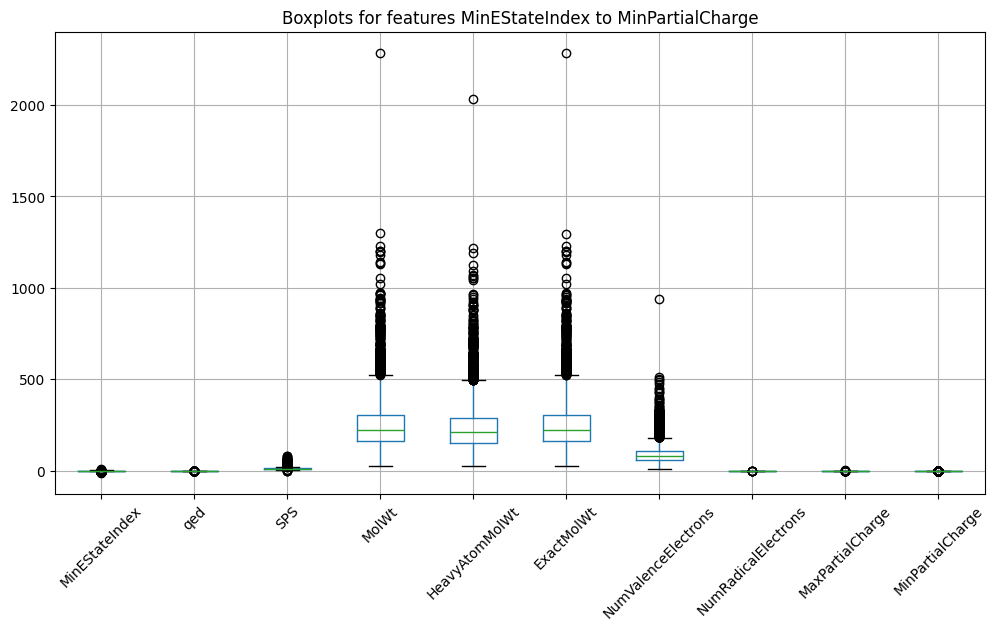

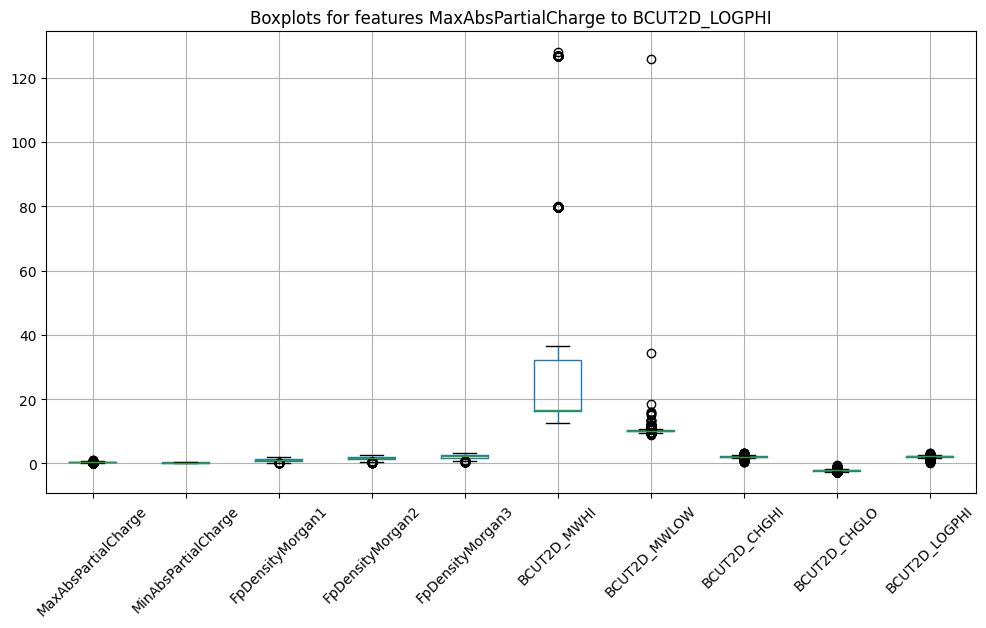

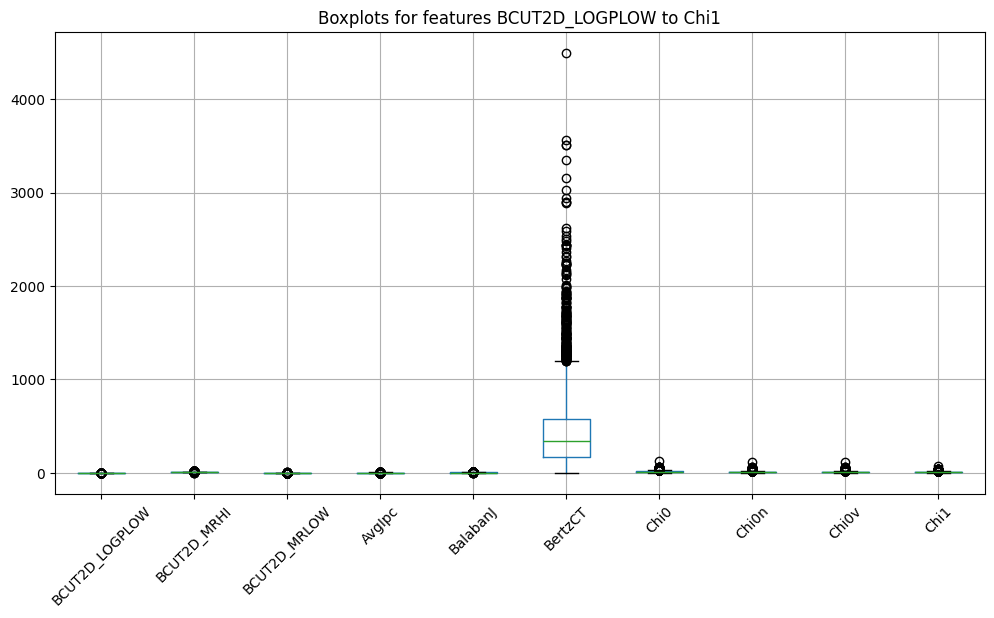

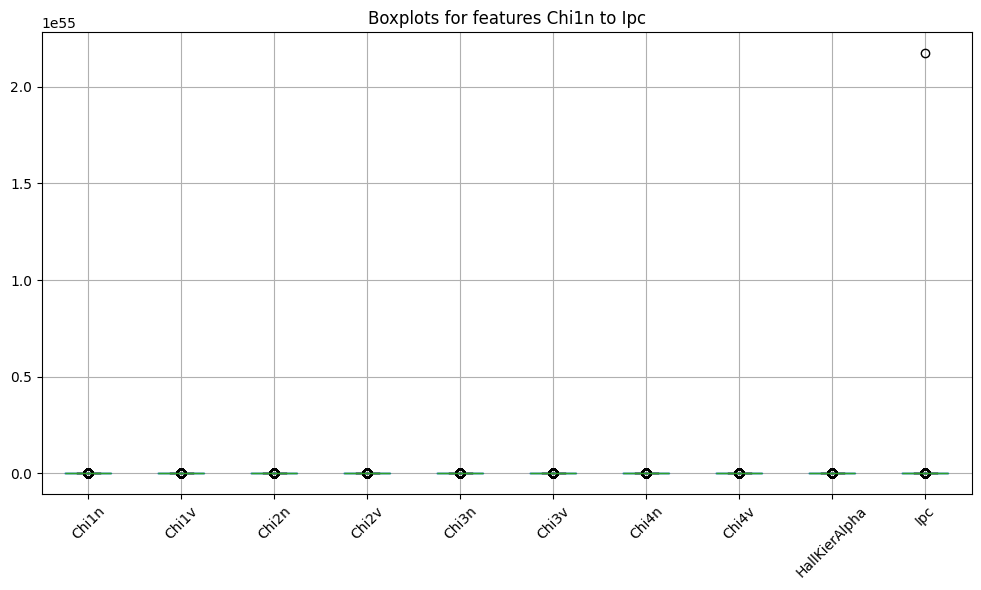

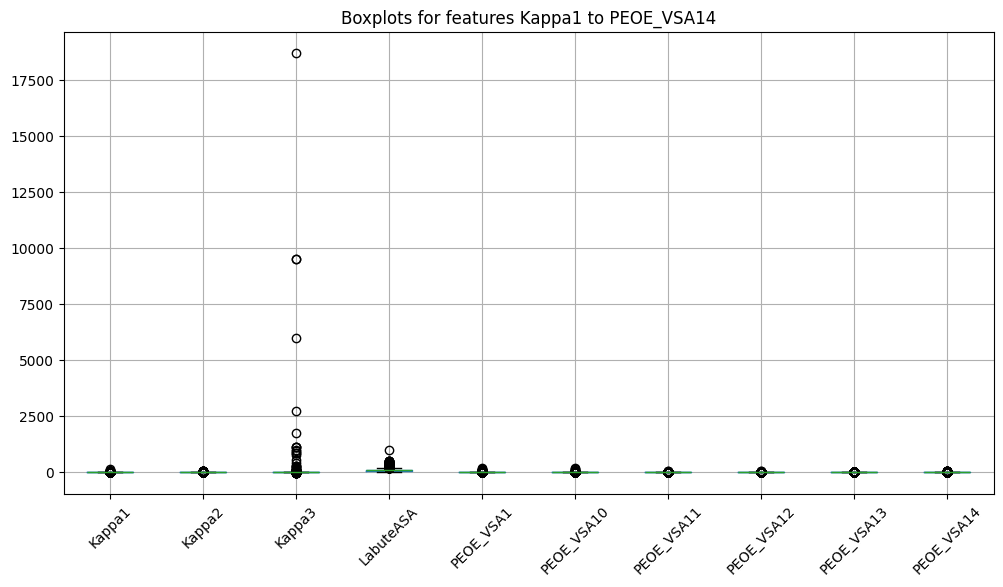

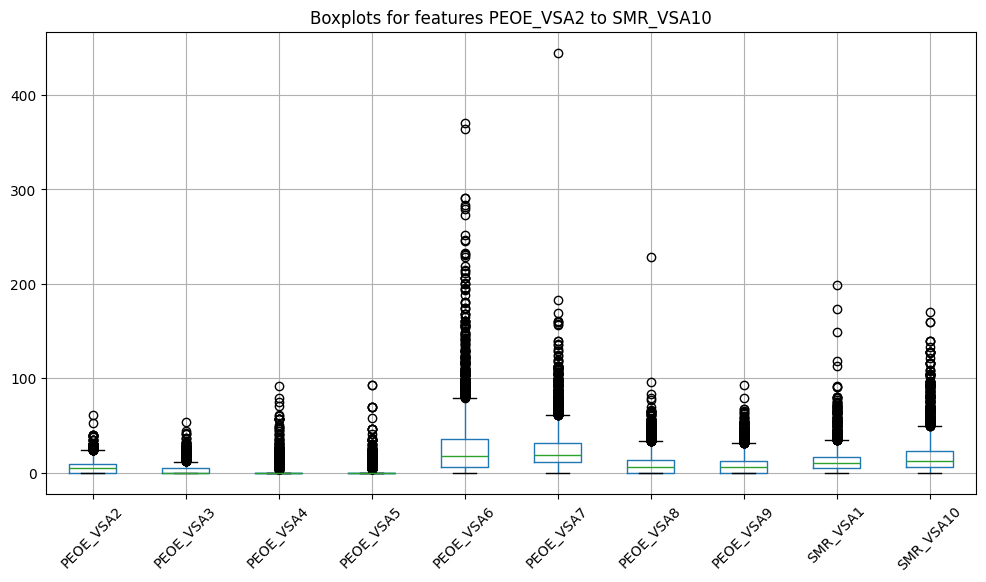

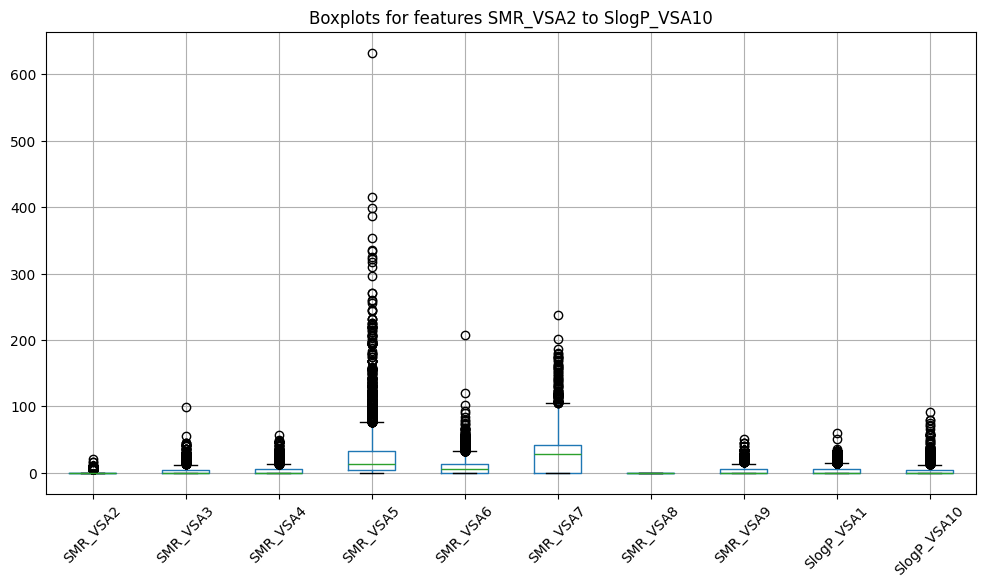

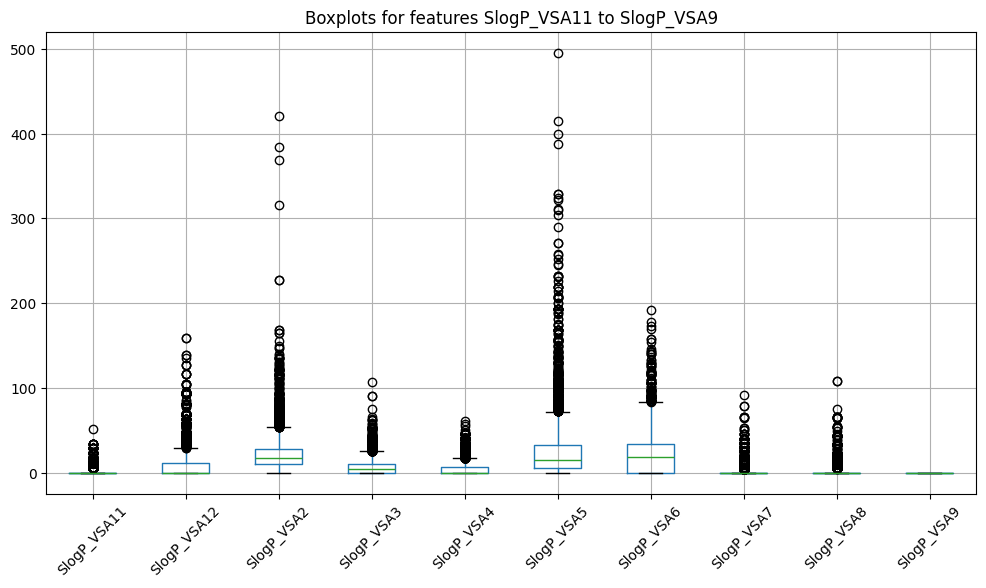

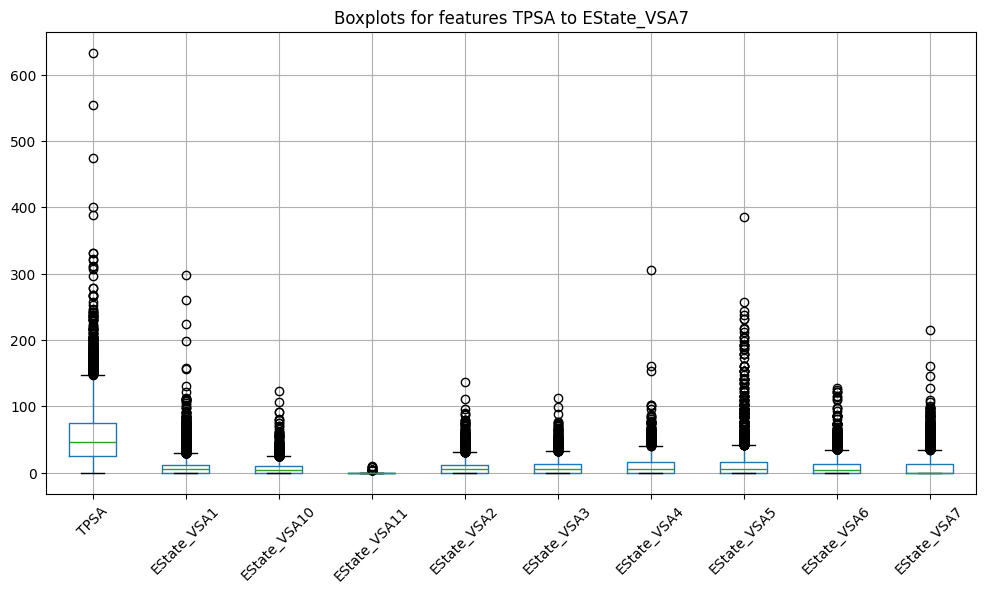

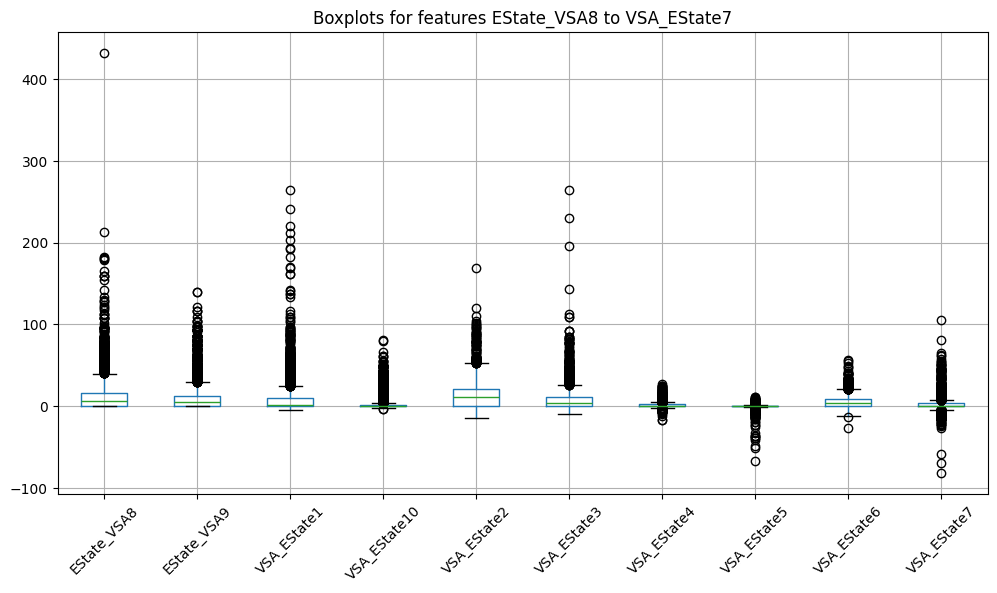

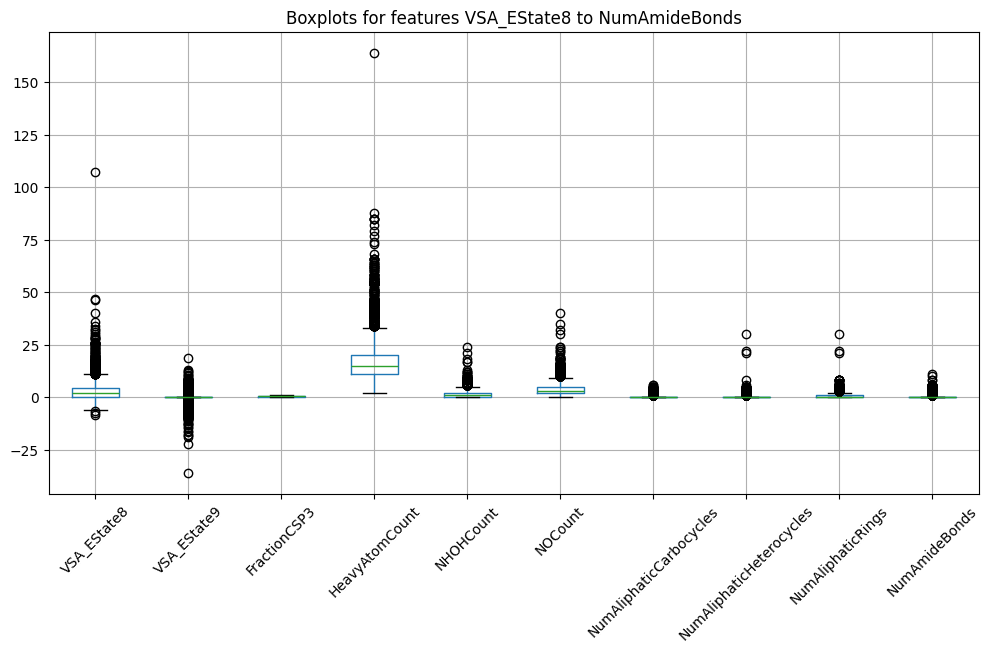

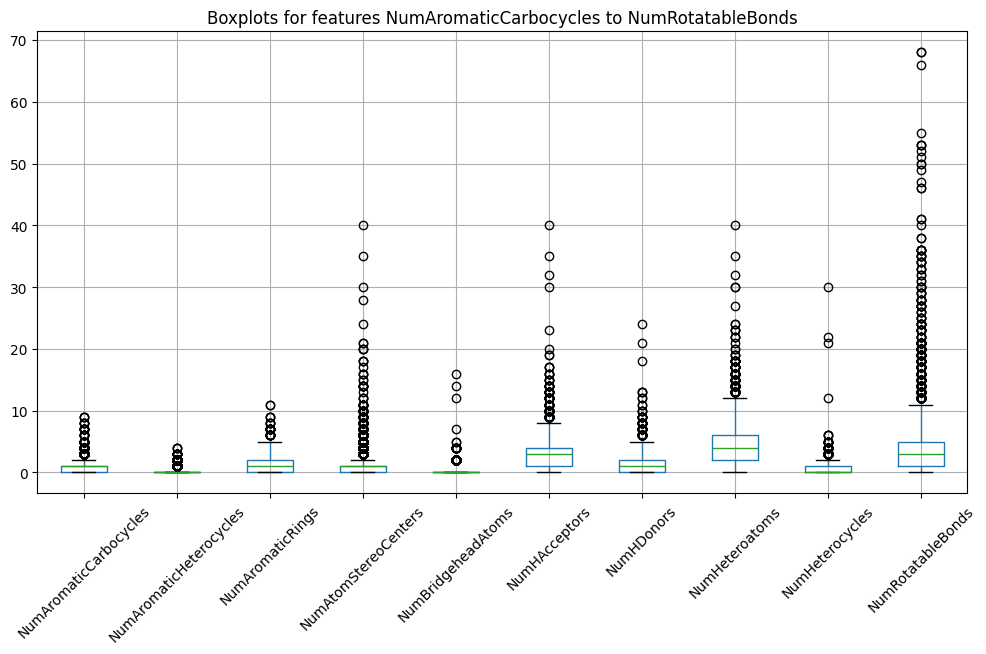

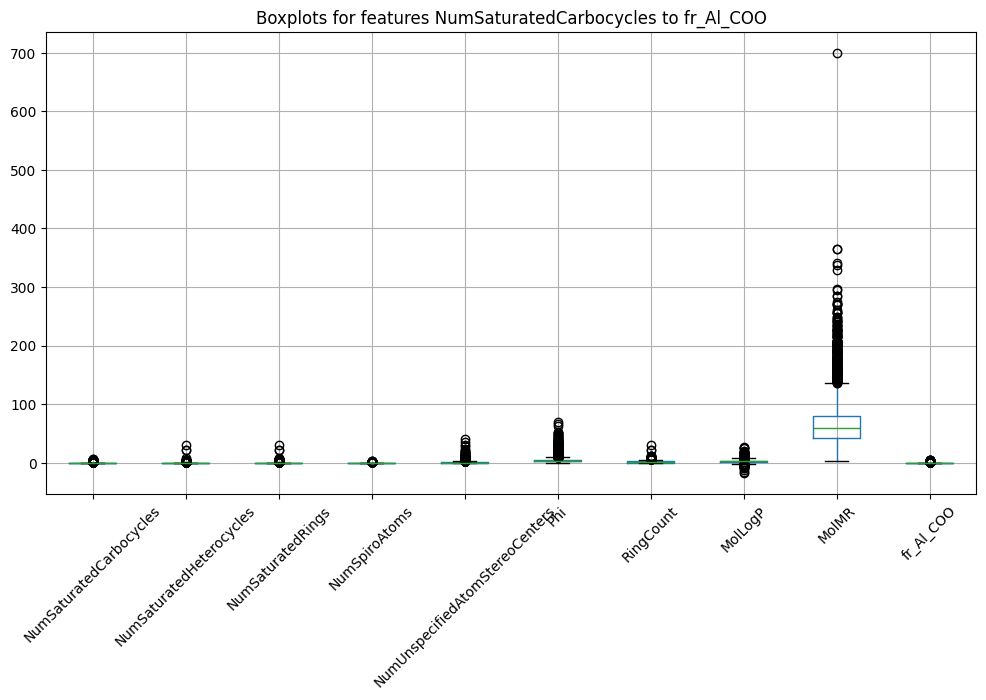

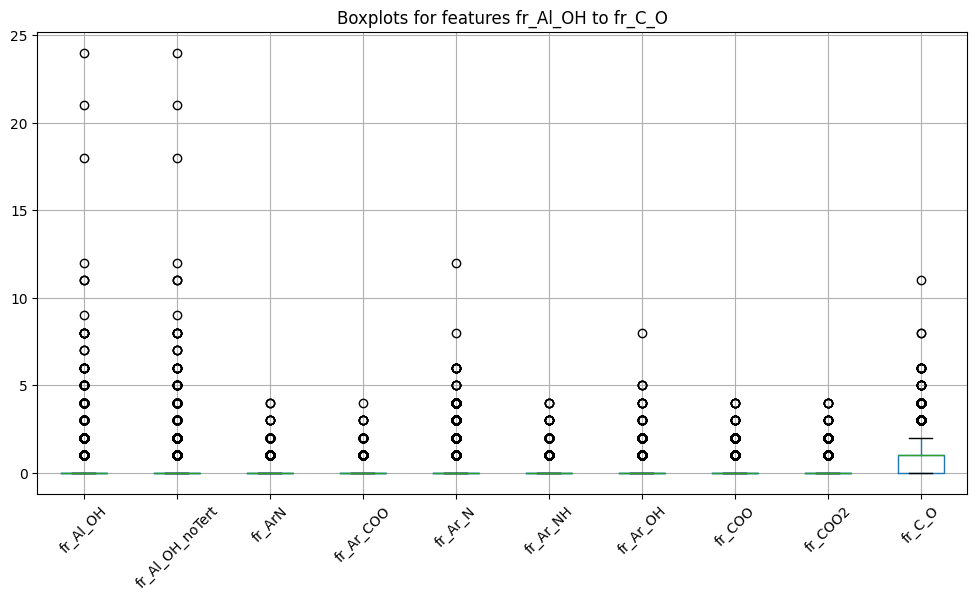

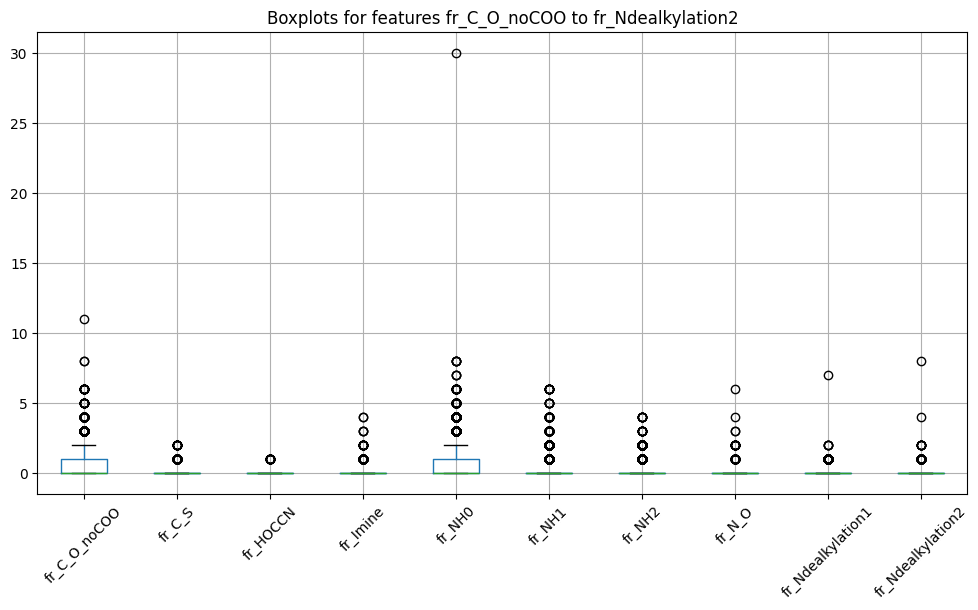

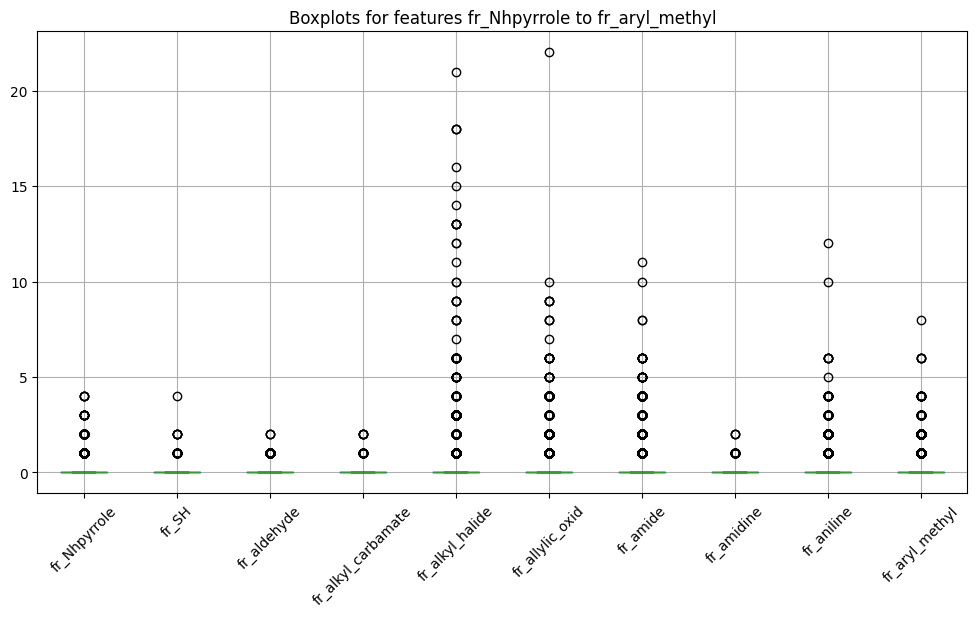

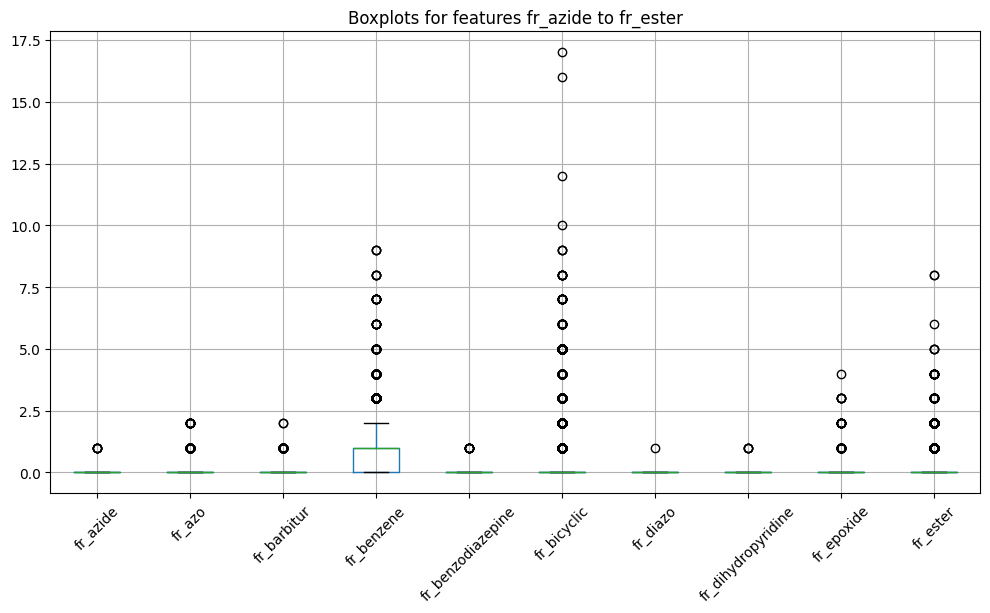

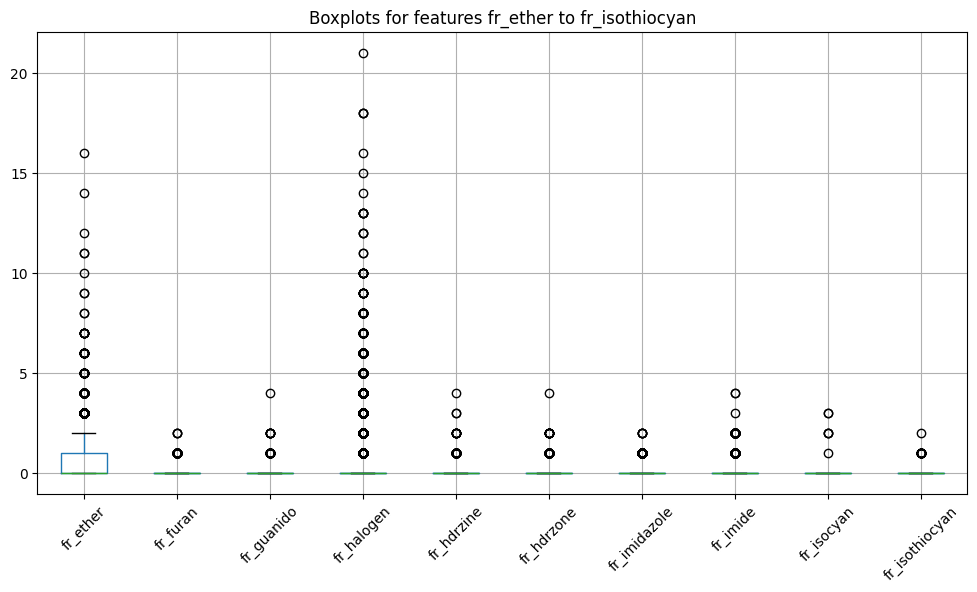

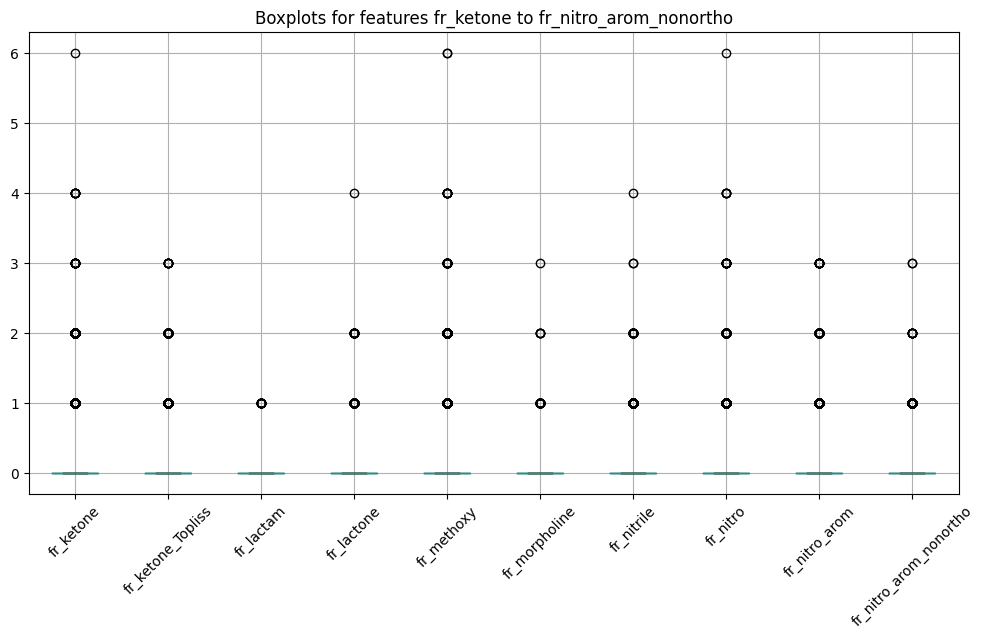

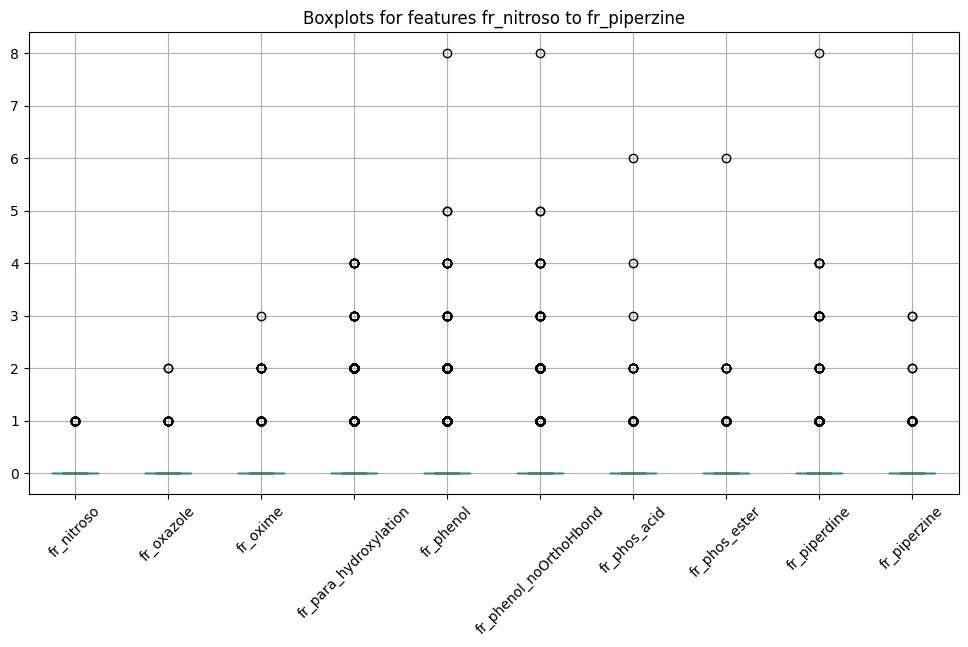

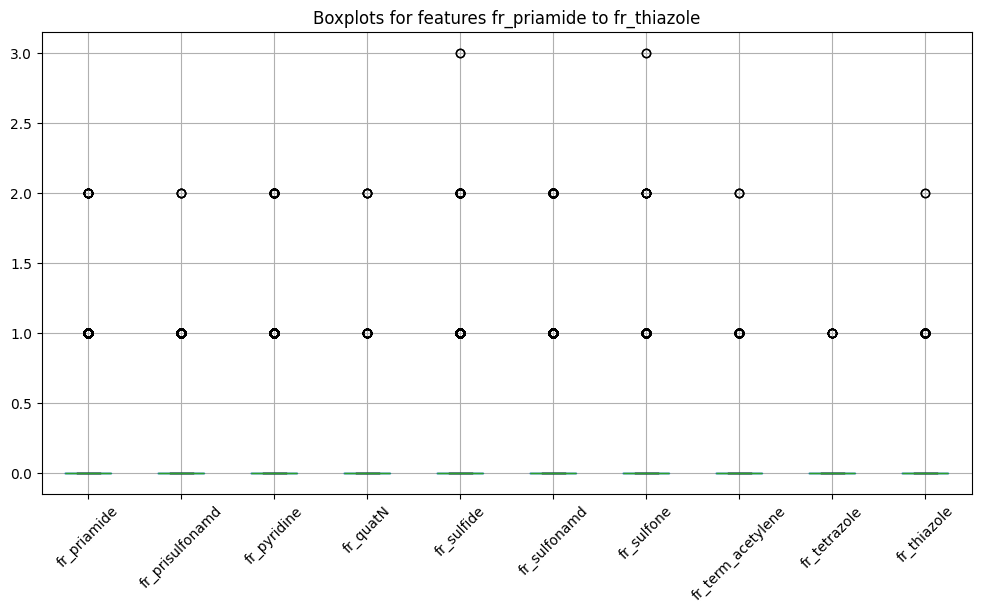

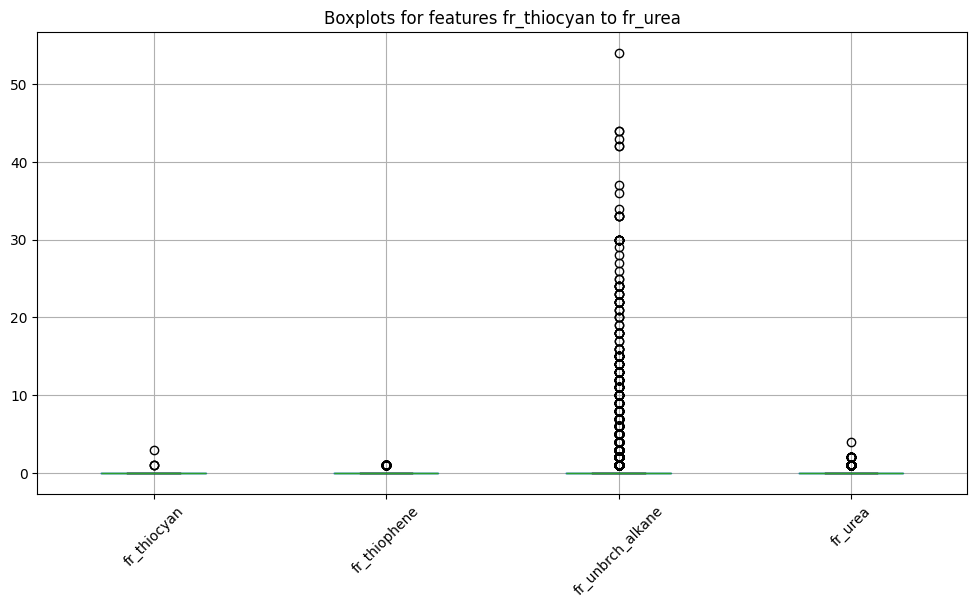

In [5]:
feature_groups = [X.columns[i:i+10] for i in range(0, len(X.columns), 10)]

for i, group in enumerate(feature_groups, 1):
    plt.figure(figsize=(12,6))
    X[group].boxplot()
    plt.title(f'Boxplots for features {group[0]} to {group[-1]}')
    plt.xticks(rotation=45)
    plt.show()

In [6]:
X_trans = pl_linear[:-1].fit_transform(X)
X_trans_df = pd.DataFrame(
    X_trans,
    columns=pl_linear[:-1].get_feature_names_out()    
)

In [7]:
cols = X.columns
dropped = [col for col in cols if col not in pl_linear[:-1].get_feature_names_out()]

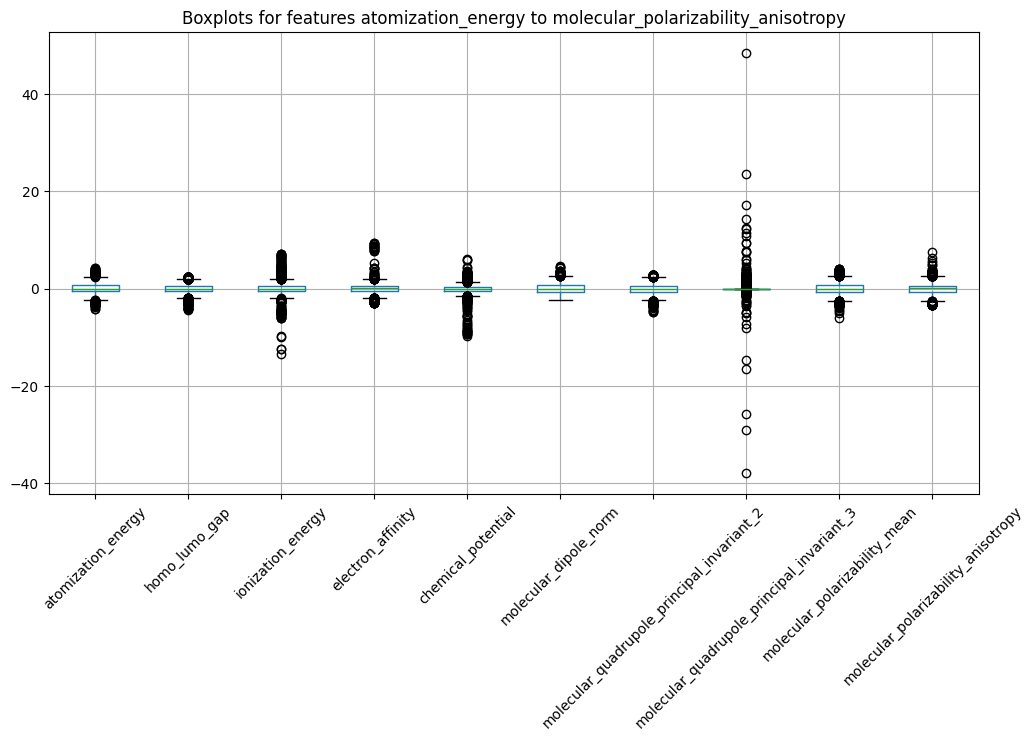

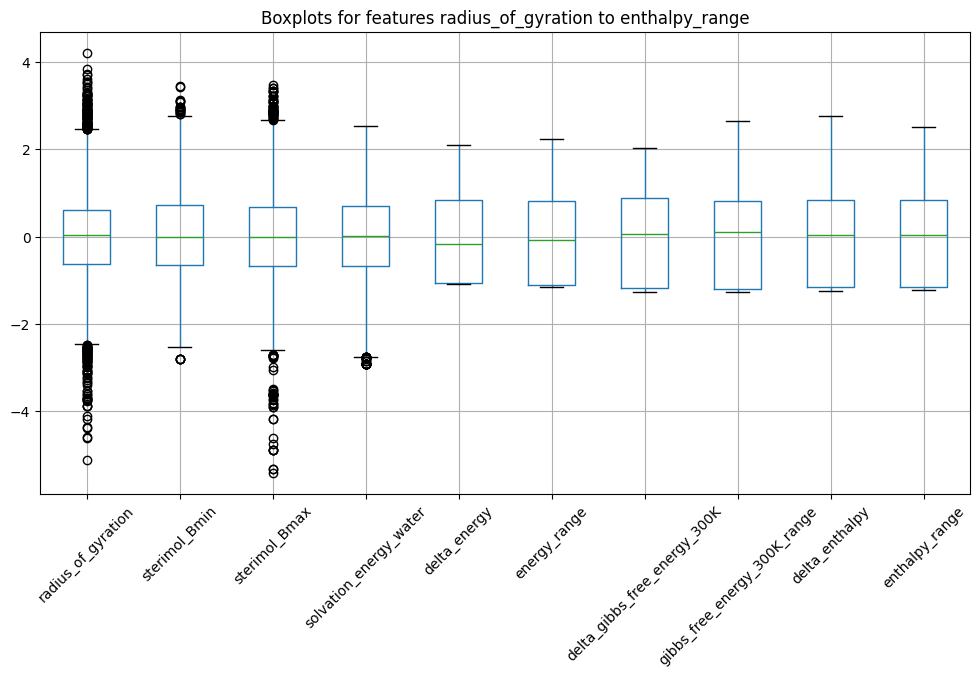

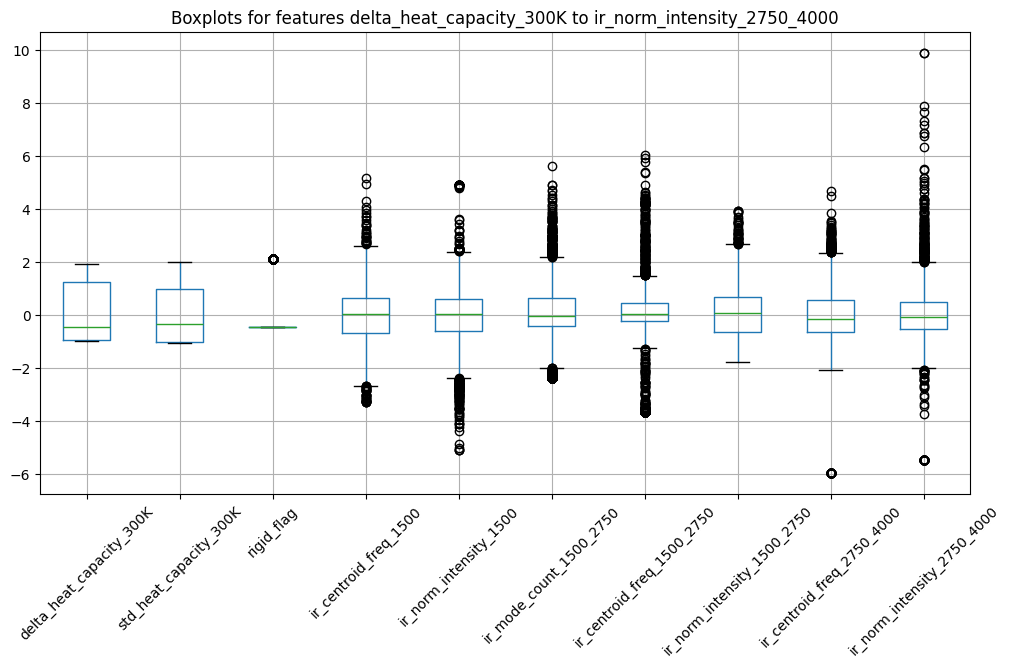

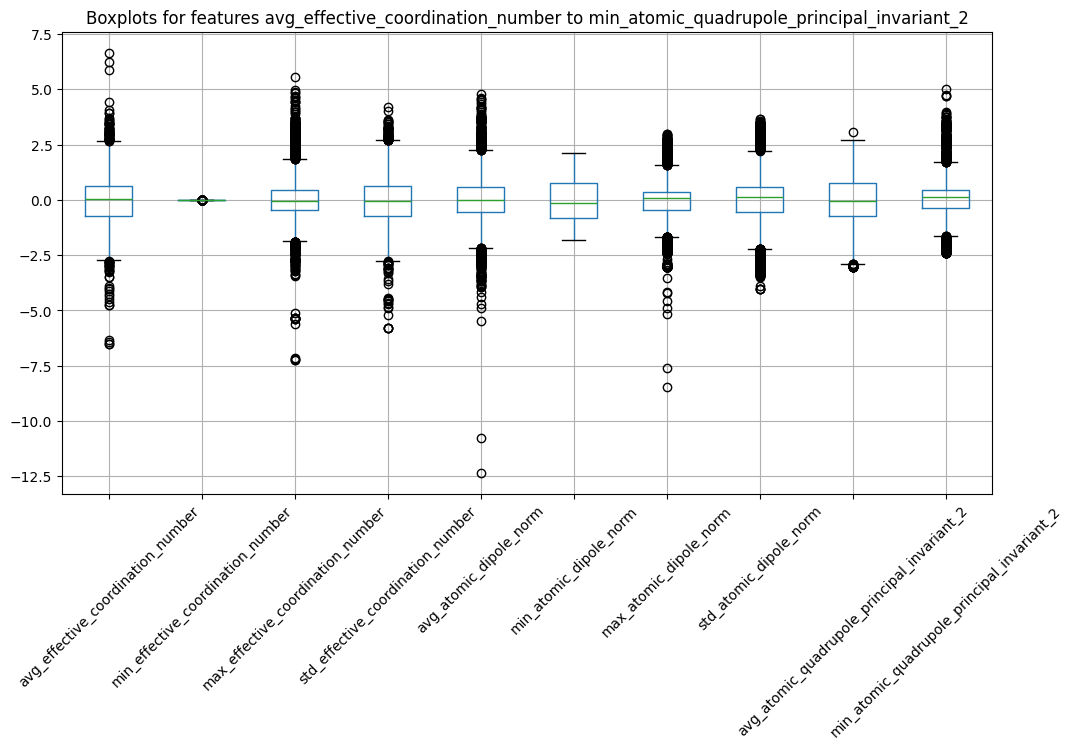

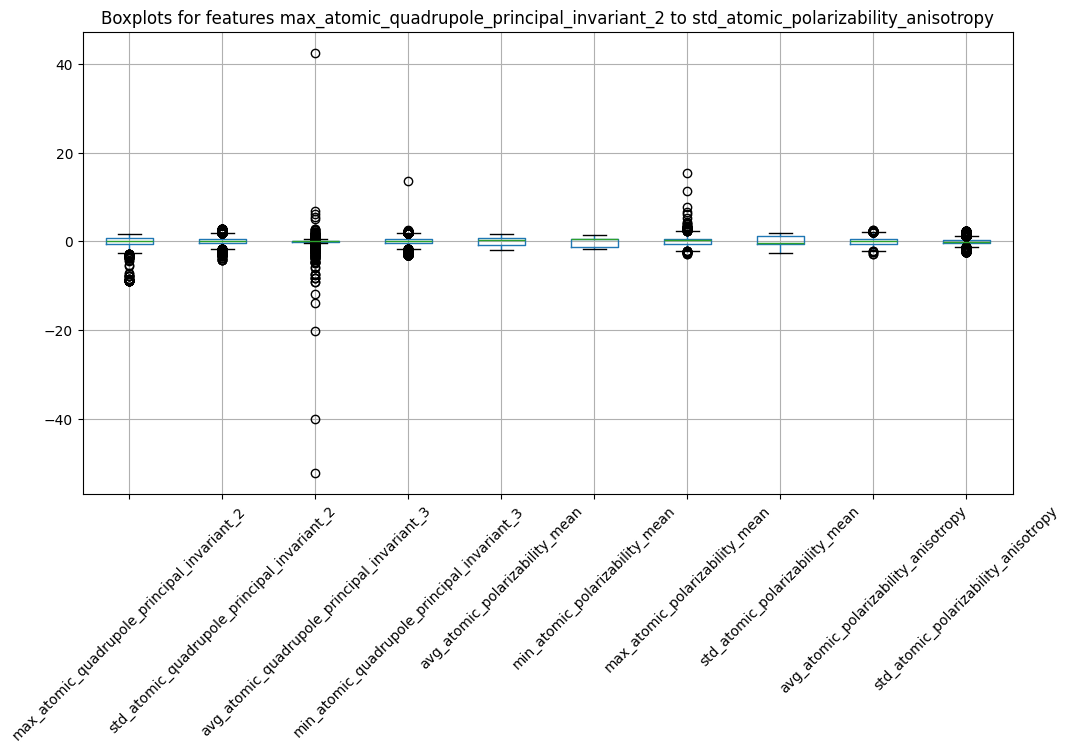

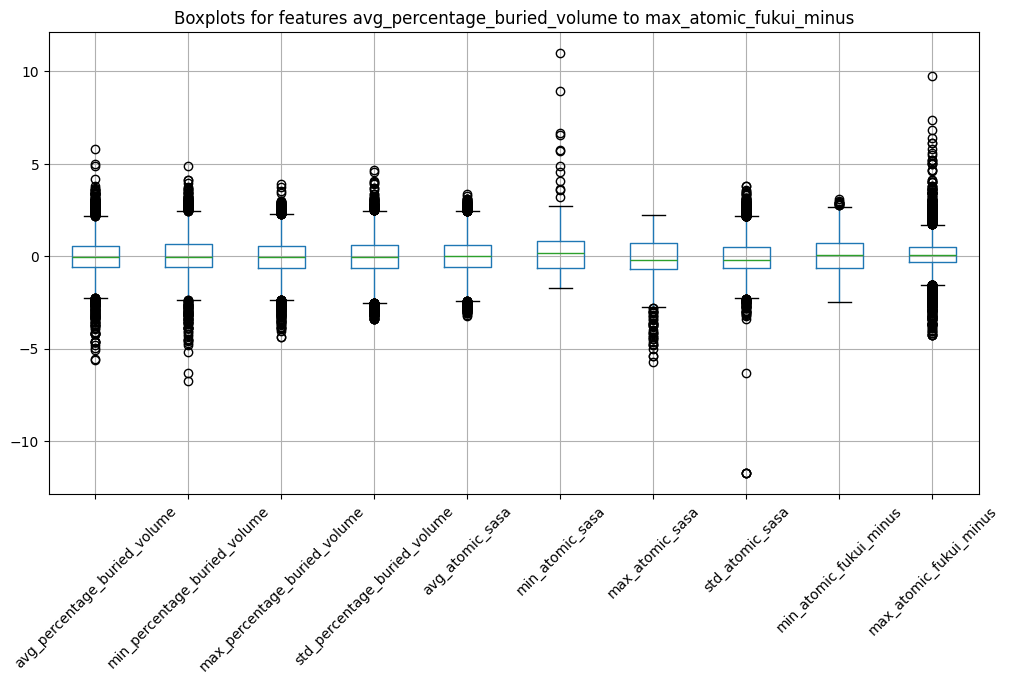

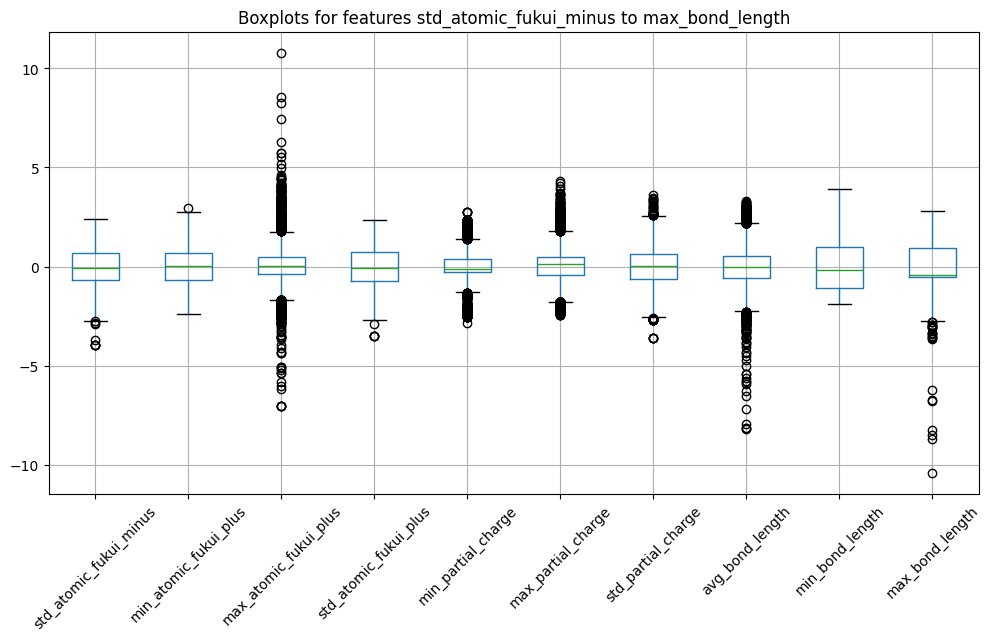

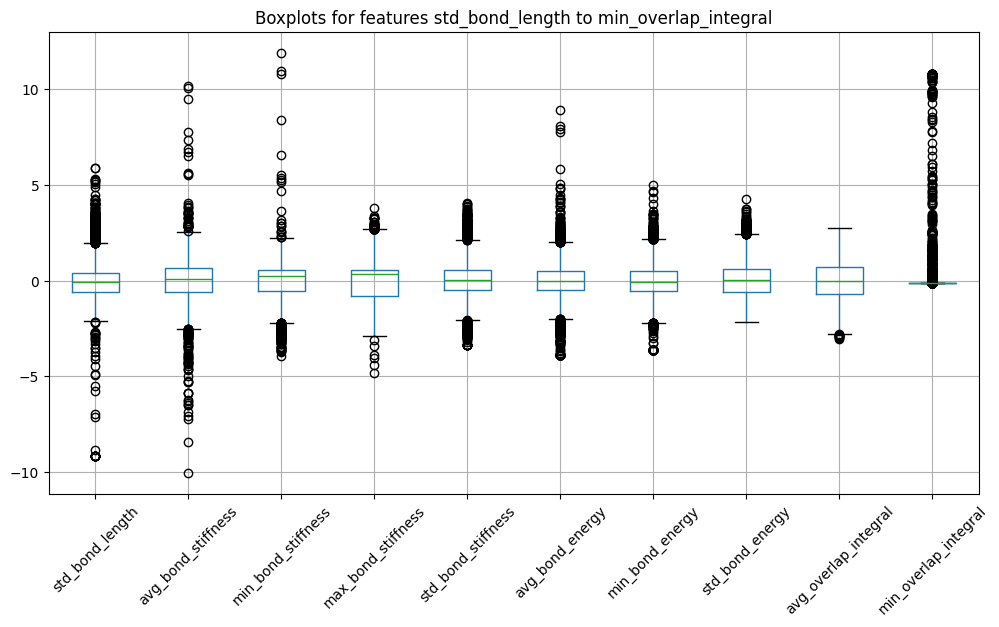

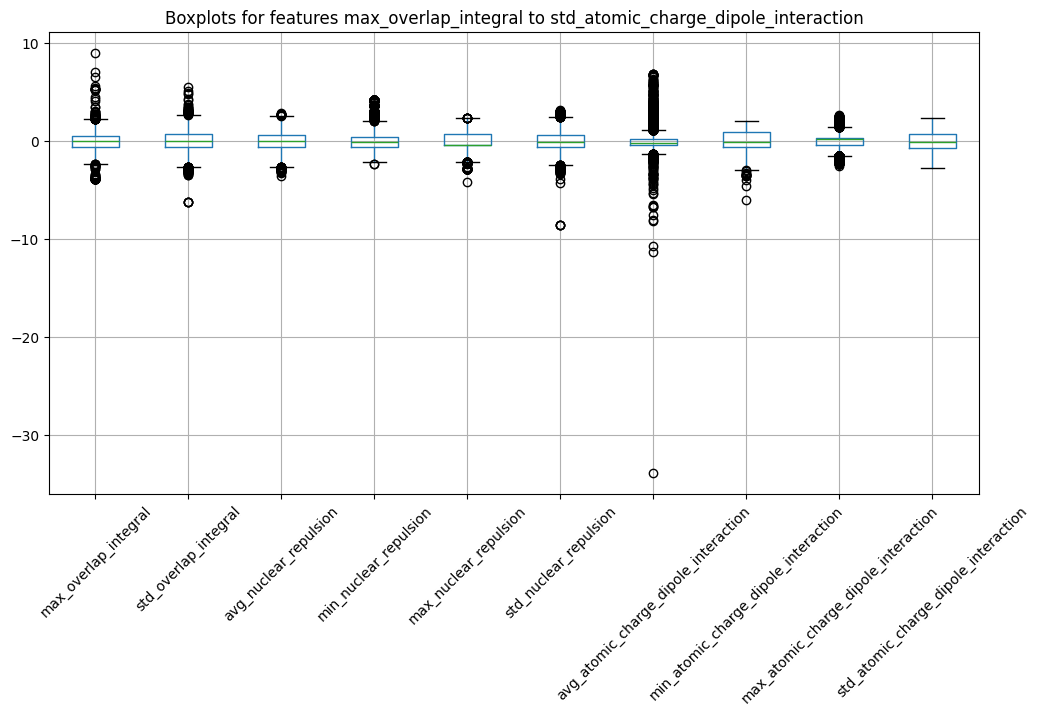

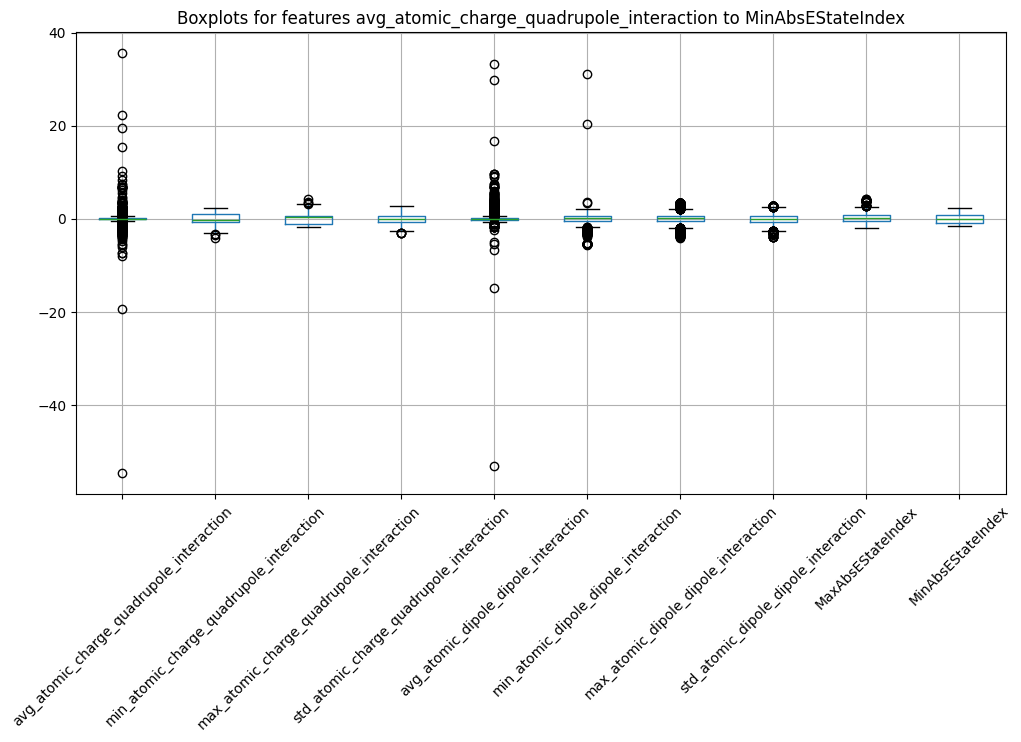

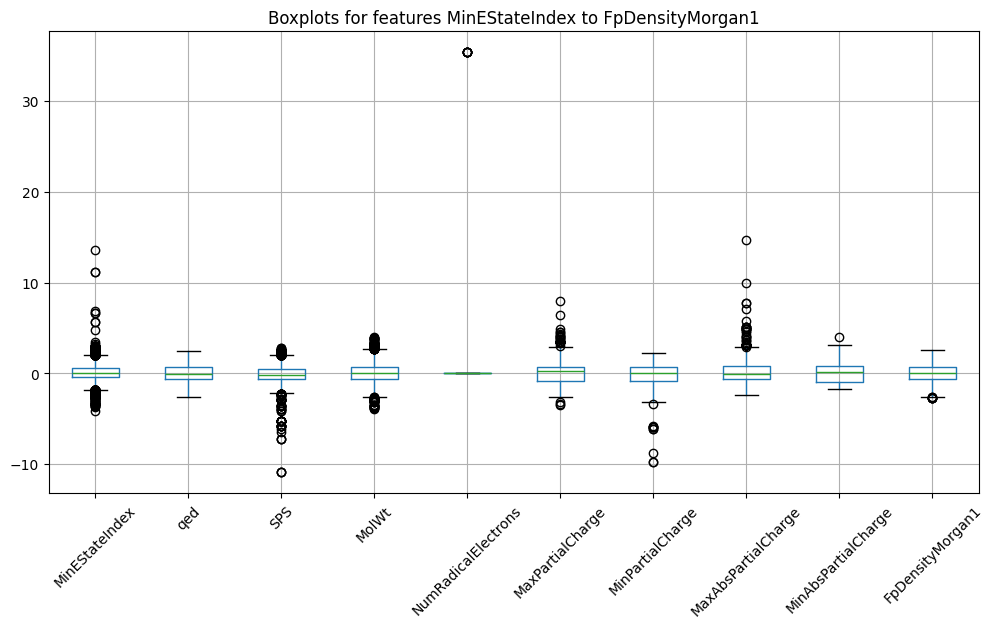

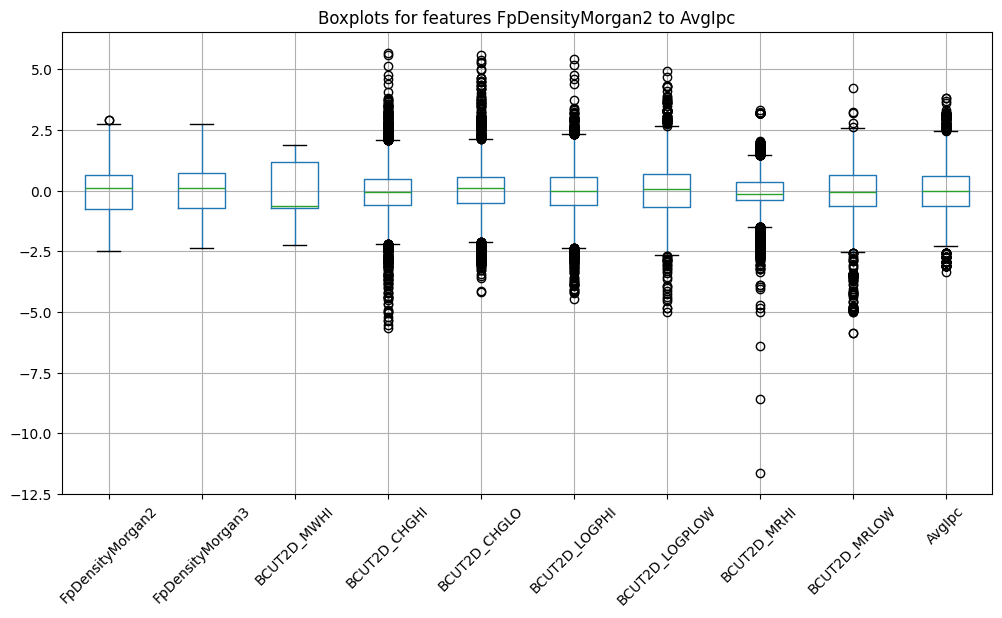

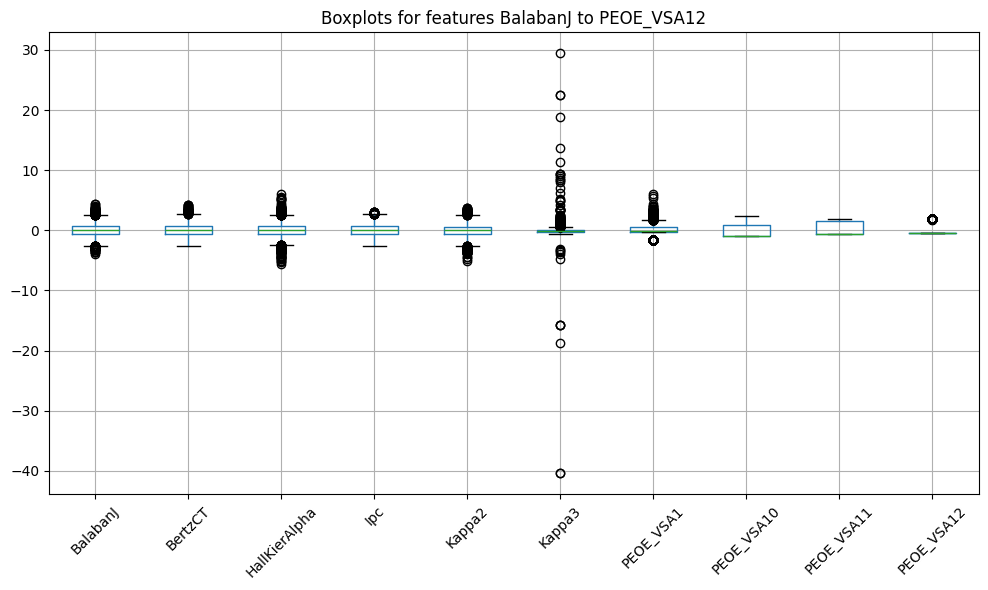

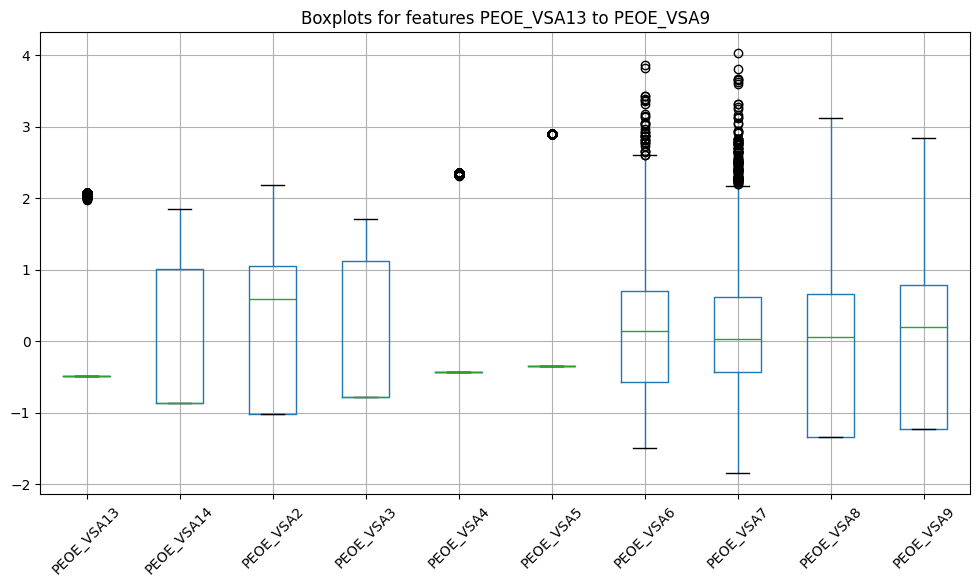

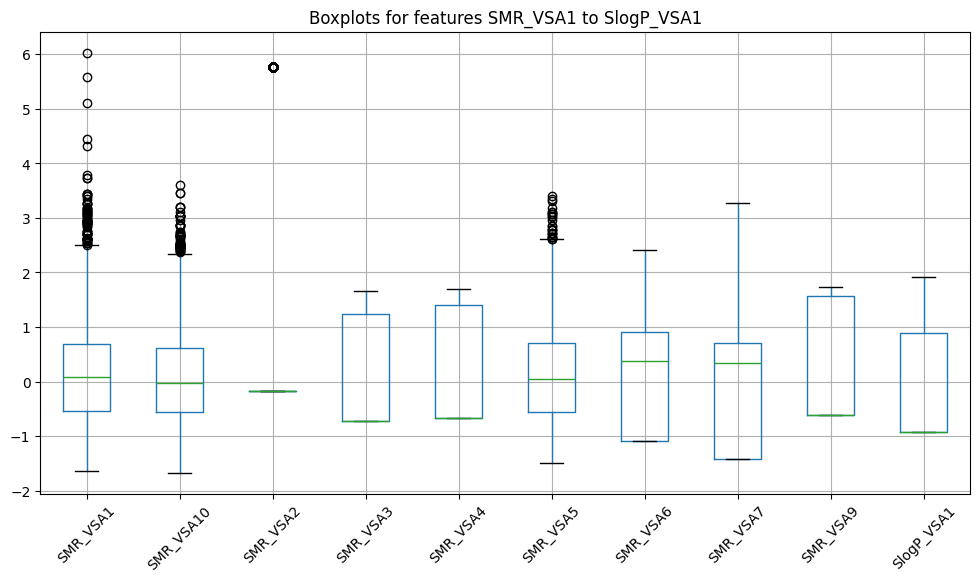

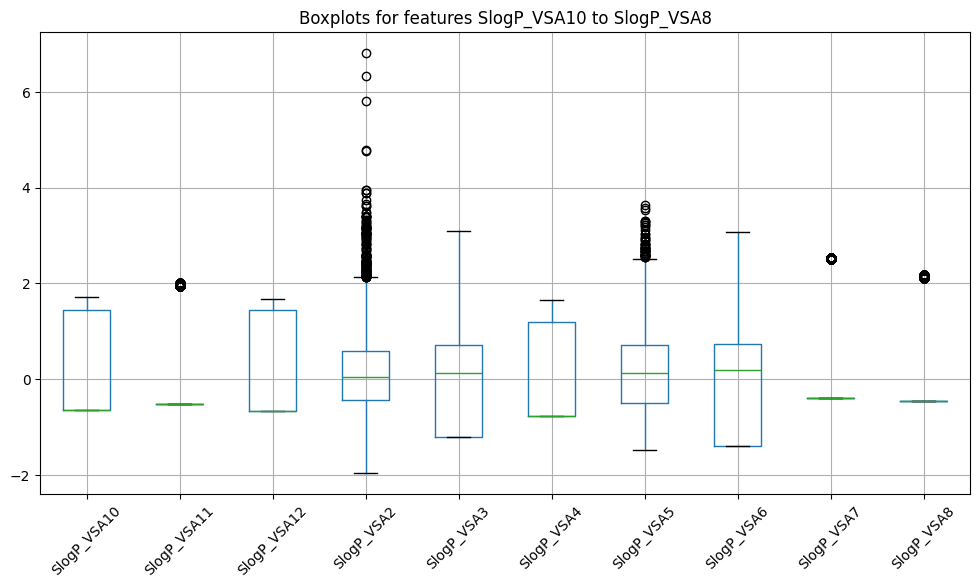

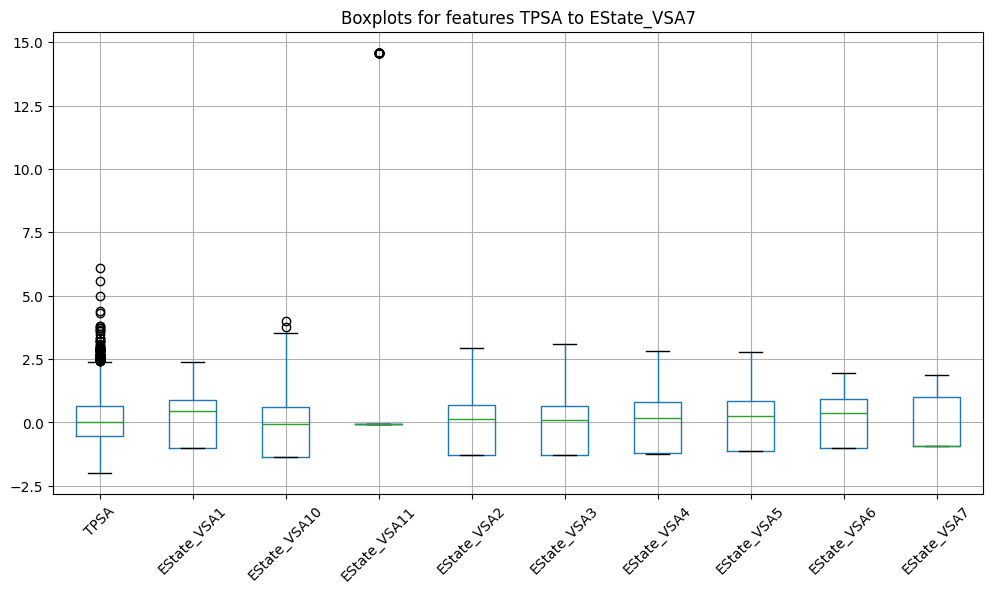

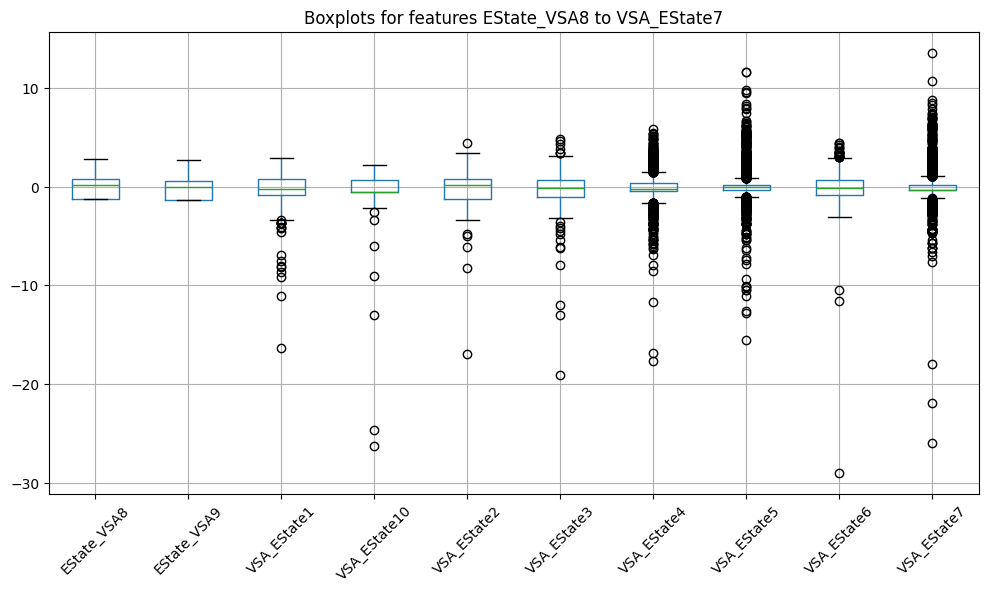

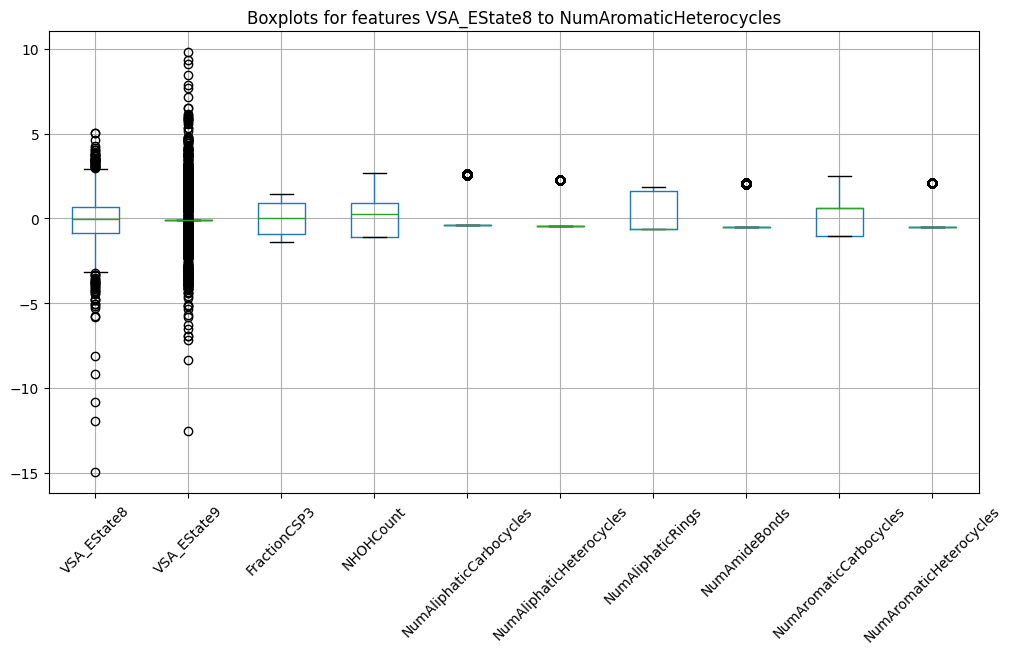

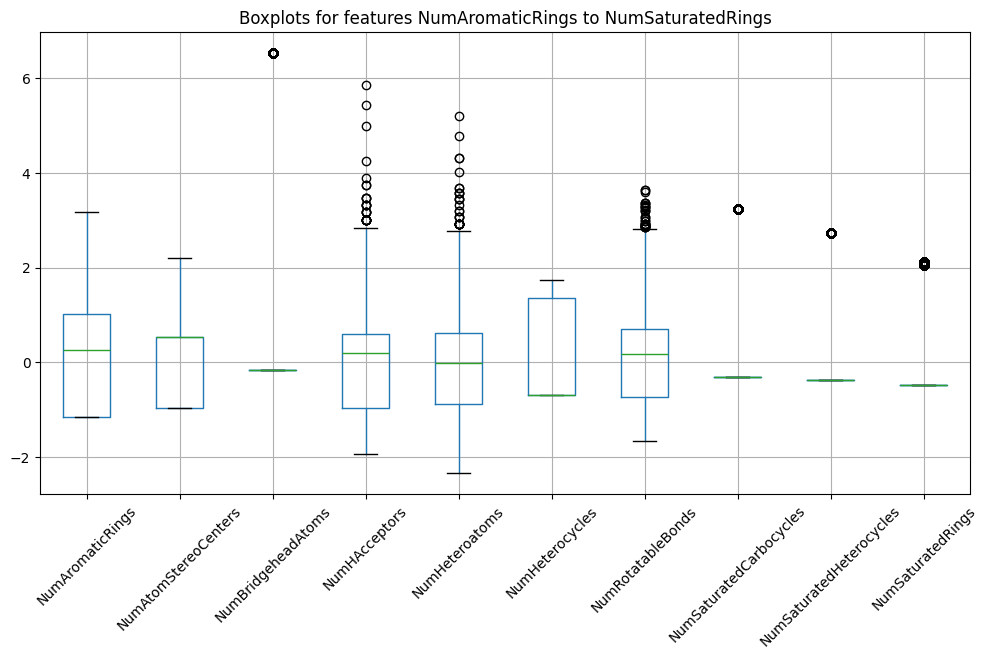

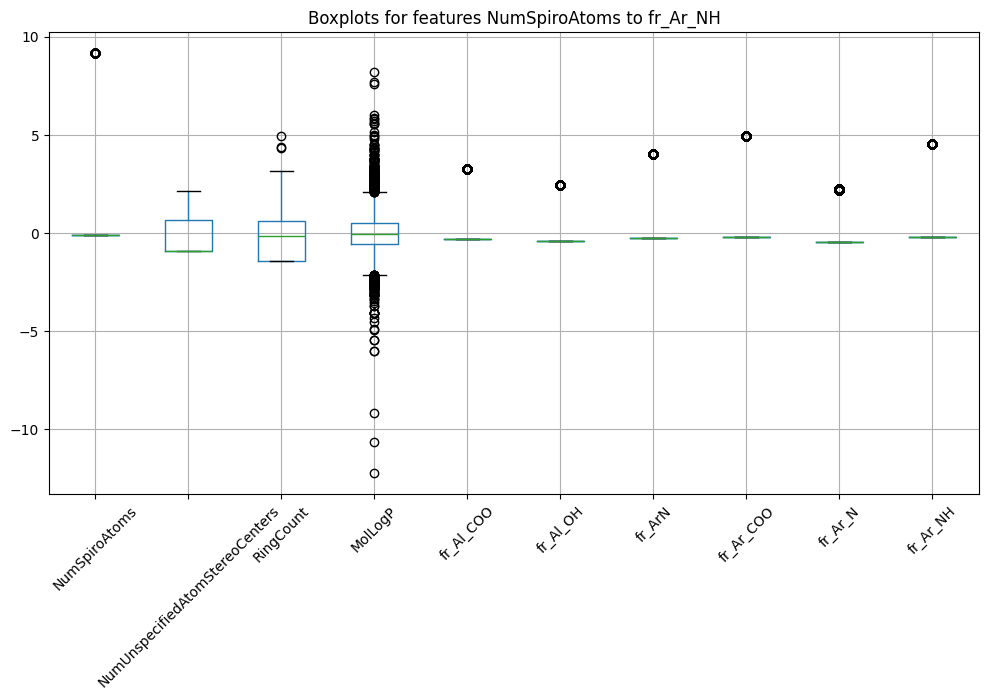

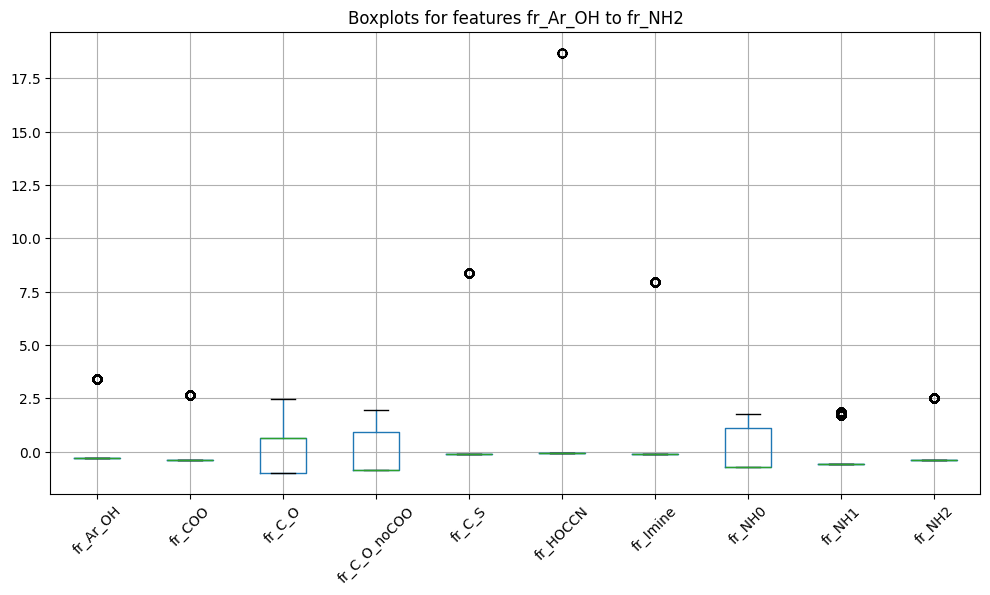

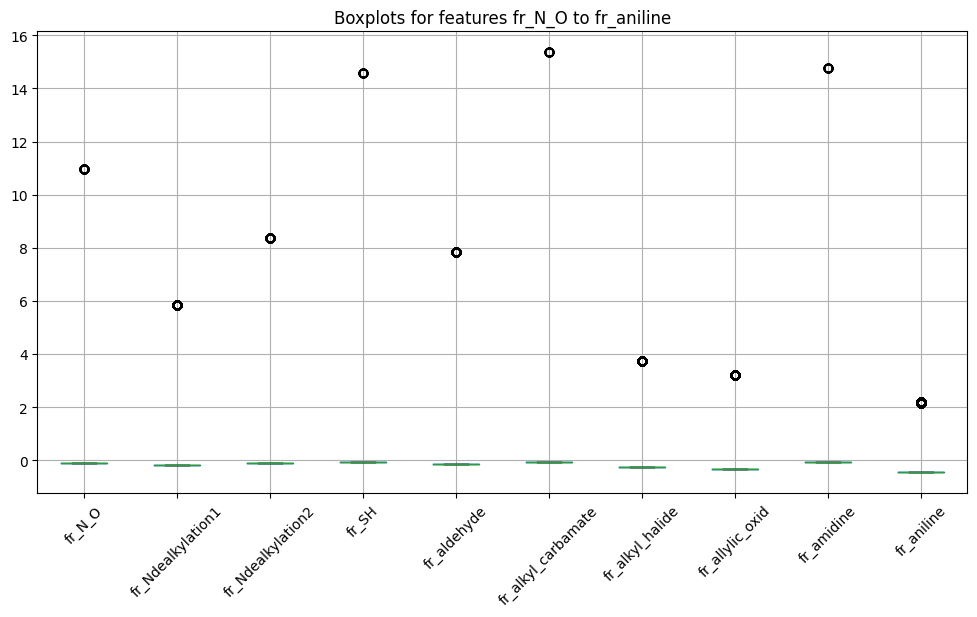

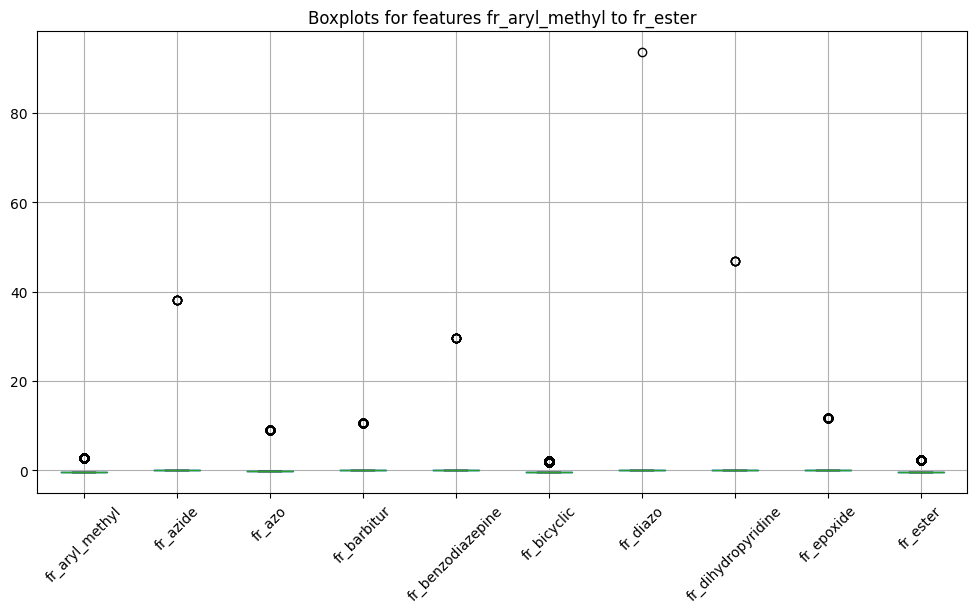

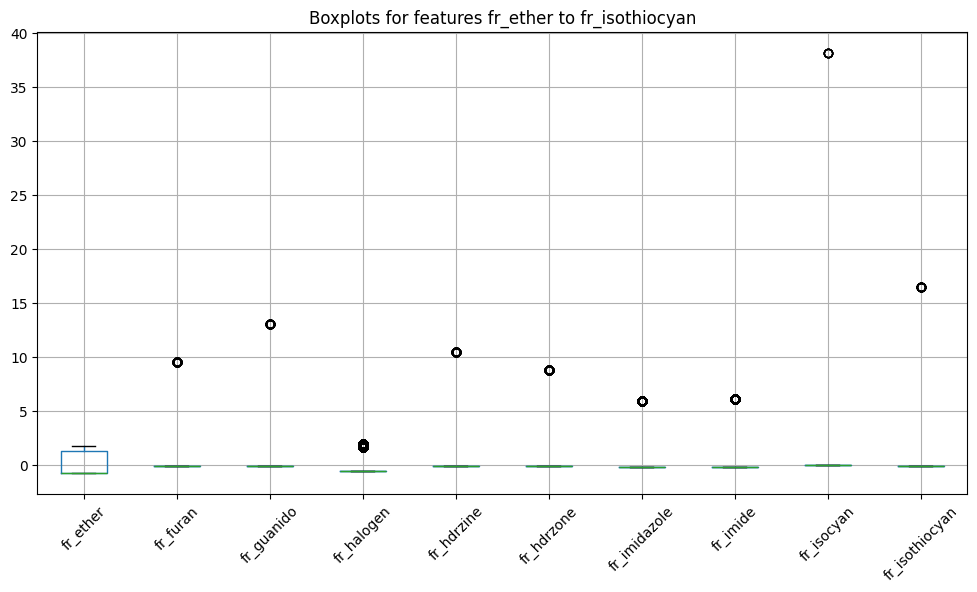

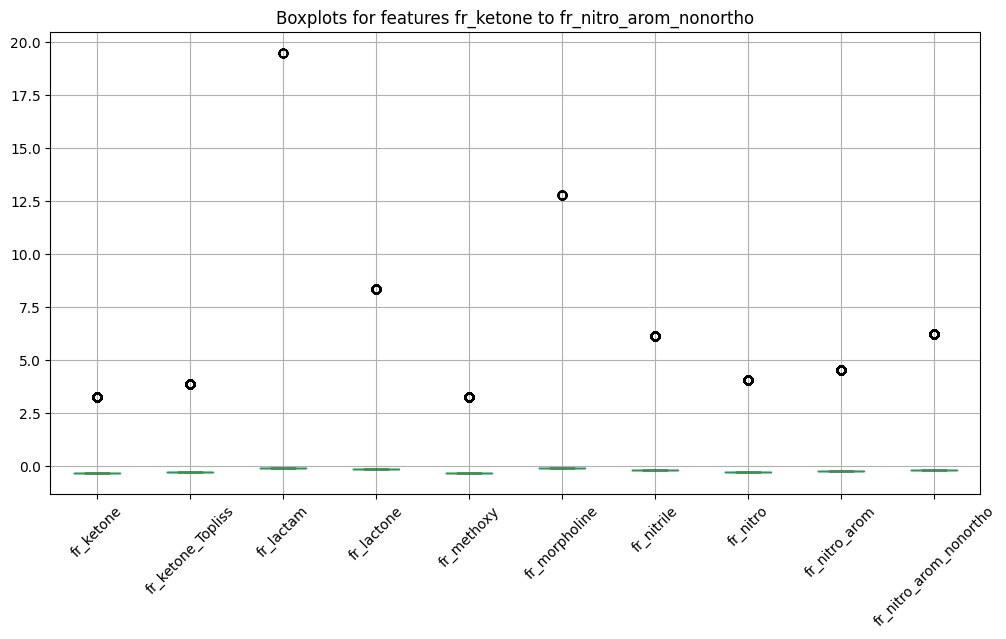

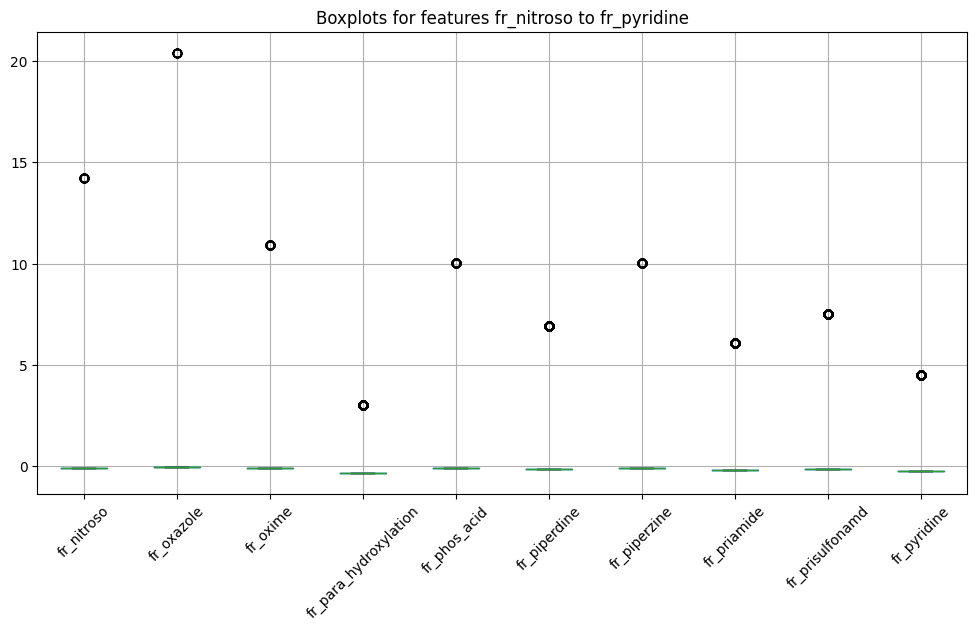

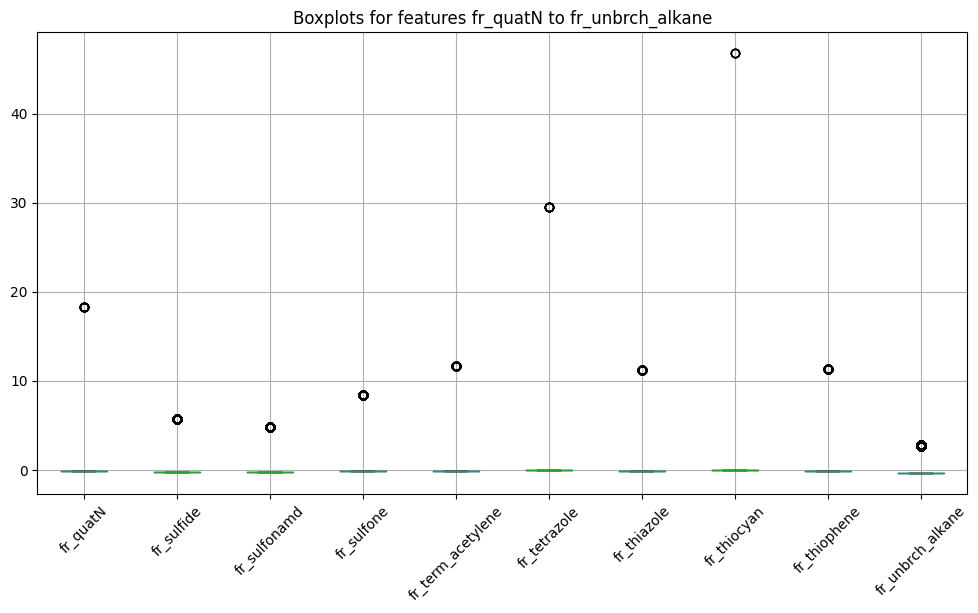

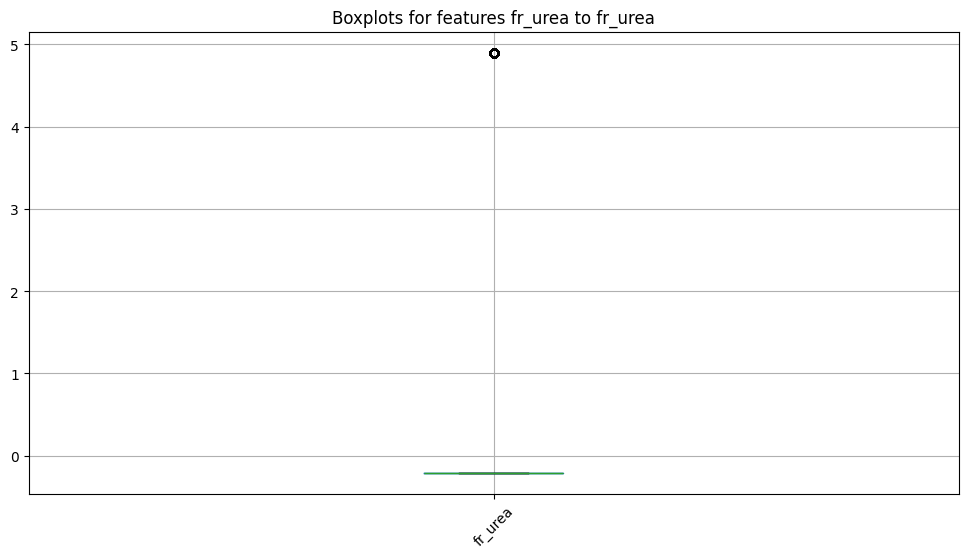

In [34]:
feature_groups = [X_trans_df.columns[i:i+10] for i in range(0, len(X_trans_df.columns), 10)]

for i, group in enumerate(feature_groups, 1):
    plt.figure(figsize=(12,6))
    X_trans_df[group].boxplot()
    plt.title(f'Boxplots for features {group[0]} to {group[-1]}')
    plt.xticks(rotation=45)
    plt.show()

In [9]:
X_trans_df["NumRadicalElectrons"].sort_values(ascending=False)[:25]

549     38.203403
812     38.203403
68      38.203403
418     38.203403
170     38.203403
283     38.203403
8       -0.026176
9       -0.026176
10      -0.026176
8731    -0.026176
26      -0.026176
8747    -0.026176
8746    -0.026176
11      -0.026176
8762    -0.026176
0       -0.026176
1       -0.026176
6       -0.026176
8748    -0.026176
8749    -0.026176
8750    -0.026176
8751    -0.026176
8752    -0.026176
8753    -0.026176
8754    -0.026176
Name: NumRadicalElectrons, dtype: float64

In [10]:
df.iloc[[811, 417, 68, 282, 170, 548]]["NumRadicalElectrons"]

811    0
417    0
68     1
282    0
170    1
548    0
Name: NumRadicalElectrons, dtype: int64

In [11]:
X_trans_df.iloc[197]["avg_atomic_charge_quadrupole_interaction"]

np.float64(-3.1497406207577314)

In [12]:
df.iloc[8658]["smiles"]

'[C:1]([C:2](/[C:3]([C:4]([H:26])([H:27])[H:28])=[N:5]/[O:6][Si:7]([C:8]([H:29])([H:30])[H:31])([O:9]/[N:10]=[C:11](\\[C:12]([H:32])([H:33])[H:34])[C:13]([C:14]([H:37])([H:38])[H:39])([H:35])[H:36])[O:15]/[N:16]=[C:17](\\[C:18]([H:40])([H:41])[H:42])[C:19]([C:20]([H:45])([H:46])[H:47])([H:43])[H:44])([H:24])[H:25])([H:21])([H:22])[H:23]'

In [13]:
'[O:1]([O:2][H:4])[H:3]'

'[O:1]([O:2][H:4])[H:3]'